# DSC 680 Project 1 - Milestone 3 - Using Polymarket Prediction Markets to Forecast S&P 500 Daily Performance
### Zicheng (Chance) Xu
### Professor: Amirfarrokh Iranitalab
### Bellevue University

## Project Introduction (Milestone 1 recap)
Prediction markets aggregate many participants’ beliefs into a single, continuously-updated probability signal (market price). Because equity prices also react to collective expectations about future events (macro data, policy, earnings surprises, geopolitical risk), I will test whether prediction-market probability signals contain measurable predictive information for short-horizon stock/ETF returns (or volatility) beyond simple baselines (e.g., buy-and-hold, moving-average, lagged returns).

In this project, I will build a time-aligned dataset that combines **prediction-market probability signals** from Polymarket (historical YES-token prices and market metadata such as category, liquidity, and volume) with **financial market data** for a target set of stocks/ETFs (daily prices/returns and common return-based indicators such as moving averages, momentum, and realized volatility). After cleaning and resampling the prediction-market series to a consistent cadence (e.g., daily), I will engineer features that capture both the *level* and *change* in market-implied probabilities (e.g., probability level, 1-day/5-day changes, rolling volatility of probabilities, and event-time proximity). I will then evaluate whether adding these prediction-market features improves short-horizon forecasting tasks—such as **next-day (or next-week) return direction**, **return magnitude**, or **volatility classification/regression**—using a small set of interpretable baseline models (logistic/linear regression) and more flexible models (tree-based methods like Random Forest / Gradient Boosting). Model performance will be measured with standard metrics appropriate to each task (e.g., **accuracy, precision/recall, F1, ROC-AUC** for direction classification; **MAE/RMSE** for regression; and where relevant, **calibration** and **out-of-sample backtest statistics** such as hit rate or simple strategy returns). Results will be compared against **benchmarks** including naïve persistence (“no-change”), lagged-return-only models, and simple technical-indicator baselines, with evaluation done using a time-series split to avoid look-ahead bias.

## 1. Data Acquisition: Prediction Market Data (Polymarket)
In this section I will extract prediction market metadata and historical probability (price) time series from Polymarket—because the whole project depends on turning “markets” into machine-learning-ready features.

Polymarket provides:
- [Gamma API for market/event metadata (public, read-only).](https://docs.polymarket.com/developers/gamma-markets-api/overview)
- [CLOB API for historical token price/probability time series via /prices-history (public endpoint for price history).](https://docs.polymarket.com/api-reference/pricing/get-price-history-for-a-traded-token)

### 1.1 Imports, paths, and notebook settings
In this subsection I will set up libraries and a reproducible folder structure—because later steps will write raw JSON and cleaned datasets to disk.

In [15]:
import os
import json
import time
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import requests
import pandas as pd

In [106]:
# Reproducible local storage (I will adjust later as needed)
PROJECT_ROOT = Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw_polymarket"
CLEAN_DIR = DATA_DIR / "clean_polymarket"

RAW_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("CLEAN_DIR:", CLEAN_DIR)

PROJECT_ROOT: /Users/ZichengXu/Desktop/Bellevue University - Master of Science Data Science/DSC 680
RAW_DIR: /Users/ZichengXu/Desktop/Bellevue University - Master of Science Data Science/DSC 680/data/raw_polymarket
CLEAN_DIR: /Users/ZichengXu/Desktop/Bellevue University - Master of Science Data Science/DSC 680/data/clean_polymarket


### 1.2 API endpoints + a safe request helper (retries + polite throttling)
In this subsection I will define endpoint constants and a “safe GET” helper—because the APIs are rate-limited and we want stable downloads. (Gamma and CLOB rate limits are documented, and requests may be throttled if exceeded.)

In [24]:
GAMMA_BASE = "https://gamma-api.polymarket.com"
CLOB_BASE  = "https://clob.polymarket.com"

EVENTS_URL = f"{GAMMA_BASE}/events"
MARKETS_URL = f"{GAMMA_BASE}/markets"
PRICES_HISTORY_URL = f"{CLOB_BASE}/prices-history"

In [26]:
def safe_get(
    url: str,
    params: Optional[Dict[str, Any]] = None,
    *,
    session: Optional[requests.Session] = None,
    timeout: int = 30,
    max_retries: int = 4,
    backoff: float = 1.5,
    polite_sleep: float = 0.10,
) -> Any:
    """
    Simple resilient GET:
      - retries w/ exponential backoff
      - small 'polite' sleep to reduce burstiness
      - returns parsed JSON
    """
    s = session or requests.Session()
    last_err = None

    for attempt in range(1, max_retries + 1):
        try:
            resp = s.get(url, params=params, timeout=timeout)
            resp.raise_for_status()
            time.sleep(polite_sleep)
            return resp.json()
        except Exception as e:
            last_err = e
            sleep_s = (backoff ** (attempt - 1))
            print(f"[safe_get] Attempt {attempt}/{max_retries} failed: {e} -> sleeping {sleep_s:.2f}s")
            time.sleep(sleep_s)

    raise RuntimeError(f"GET failed after {max_retries} attempts: {url}") from last_err

### 1.3 Pull events (paginated) from the Gamma API
In this subsection I will download events (and their nested markets) from the Gamma API—because events is the most efficient way to retrieve many markets at once (events include associated markets).

Pagination approach: limit + offset (increment offset by limit until an empty page).

In [34]:
def fetch_events(
    *,
    closed: bool = False,
    limit: int = 100,
    max_pages: Optional[int] = None,
    order: str = "id",
    ascending: bool = False,
    start_date_min: Optional[str] = None,
    end_date_max: Optional[str] = None,
) -> List[Dict[str, Any]]:
    """
    Fetch events from Gamma /events with pagination.

    Params (Gamma):
      - closed: false => active markets (recommended for "current" discovery)
      - limit, offset: pagination
      - order, ascending: stable ordering
      - start_date_min, end_date_max: optional ISO timestamps
    """
    all_events: List[Dict[str, Any]] = []
    offset = 0
    page = 0
    sess = requests.Session()

    while True:
        page += 1
        params: Dict[str, Any] = {
            "closed": str(closed).lower(),
            "limit": limit,
            "offset": offset,
            "order": order,
            "ascending": str(ascending).lower(),
        }
        if start_date_min:
            params["start_date_min"] = start_date_min
        if end_date_max:
            params["end_date_max"] = end_date_max

        batch = safe_get(EVENTS_URL, params=params, session=sess)

        if not isinstance(batch, list):
            raise ValueError(f"Expected list response from /events, got: {type(batch)}")

        if len(batch) == 0:
            break

        all_events.extend(batch)
        offset += limit

        print(f"Fetched page={page} events={len(batch)} total={len(all_events)} offset={offset}")

        if max_pages is not None and page >= max_pages:
            break

    return all_events

In [36]:
# Example: pull a small sample first (fast sanity check)
events_sample = fetch_events(closed=False, limit=50, max_pages=2)

raw_path = RAW_DIR / "gamma_events_sample.json"
raw_path.write_text(json.dumps(events_sample, indent=2))
print("Wrote:", raw_path, "events:", len(events_sample))

Fetched page=1 events=50 total=50 offset=50
Fetched page=2 events=50 total=100 offset=100
Wrote: /Users/ZichengXu/Desktop/Bellevue University - Master of Science Data Science/DSC 680/data/raw_polymarket/gamma_events_sample.json events: 100


The code is working as intended. The output shows it successfully paginated through the Gamma `/events` endpoint twice (50 events per page), collected **100 total events**, and saved them into the JSON file at the path printed. When I open the file, the structure looks correct: each **event** has high-level details (title, dates, active/closed flags, description, etc.) and contains a nested **`markets`** list with the actual tradable market information. In the example file, an example event is an “XRP Up or Down” market, and inside `markets` I can see the two outcomes (“Up” and “Down”) plus two `clobTokenIds`—those token IDs are exactly what we need for the next step (pulling historical price/probability time series from the CLOB `prices-history` endpoint). So at this stage, the data pull and file export are correct, and we’ve confirmed the API response contains the key fields required to build the modeling dataset.

### 1.4 Flatten nested markets into a tidy “market metadata” table
In this subsection I will flatten events -> markets[] into a single table—because modeling will be done at the market-token time series level, not nested JSON. (The events response includes a markets array with fields like outcomes, outcomePrices, and clobTokenIds.)

In [40]:
def _jsonish_list(x: Any) -> List[Any]:
    """
    Gamma sometimes returns list-like fields as JSON strings (e.g. '["Yes","No"]').
    This helper normalizes them into Python lists.
    """
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("[") and x.endswith("]"):
            try:
                return json.loads(x)
            except json.JSONDecodeError:
                return []
    return []

def events_to_markets_df(events: List[Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for ev in events:
        ev_id = ev.get("id")
        ev_title = ev.get("title")
        ev_slug = ev.get("slug")
        ev_category = ev.get("category")
        ev_end = ev.get("endDate") or ev.get("endDateIso")

        for m in (ev.get("markets") or []):
            outcomes = _jsonish_list(m.get("outcomes"))
            outcome_prices = _jsonish_list(m.get("outcomePrices"))
            clob_token_ids = _jsonish_list(m.get("clobTokenIds"))

            rows.append({
                "event_id": ev_id,
                "event_title": ev_title,
                "event_slug": ev_slug,
                "event_category": ev_category,
                "event_end": ev_end,

                "market_id": m.get("id"),
                "market_question": m.get("question"),
                "market_slug": m.get("slug"),
                "market_category": m.get("category"),
                "start_date": m.get("startDate") or m.get("startDateIso"),
                "end_date": m.get("endDate") or m.get("endDateIso"),
                "volume_num": m.get("volumeNum"),
                "liquidity_num": m.get("liquidityNum"),
                "enable_order_book": m.get("enableOrderBook"),

                "outcomes": outcomes,
                "outcome_prices": outcome_prices,
                "clob_token_ids": clob_token_ids,
            })

    df = pd.DataFrame(rows)
    return df

In [42]:
markets_sample_df = events_to_markets_df(events_sample)

print("markets_sample_df shape:", markets_sample_df.shape)
markets_sample_df.head(5)

markets_sample_df shape: (155, 17)


,event_id,event_title,event_slug,event_category,event_end,market_id,market_question,market_slug,market_category,start_date,end_date,volume_num,liquidity_num,enable_order_book,outcomes,outcome_prices,clob_token_ids
0,105157,"XRP Up or Down - December 15, 1:00PM-1:15PM ET",xrp-updown-15m-1765821600,None,2025-12-15T18:15:00Z,933707,"XRP Up or Down - December 15, 1:00PM-1:15PM ET",xrp-updown-15m-1765821600,None,2025-12-14T18:02:49.013737Z,2025-12-15T18:15:00Z,0.0,0.0,True,"[Up, Down]",[],[457654149051441455342697608417864291258742311...
1,105156,"Ethereum Up or Down - December 15, 1:00PM-1:15...",eth-updown-15m-1765821600,None,2025-12-15T18:15:00Z,933706,"Ethereum Up or Down - December 15, 1:00PM-1:15...",eth-updown-15m-1765821600,None,2025-12-14T18:02:47.261691Z,2025-12-15T18:15:00Z,0.0,0.0,True,"[Up, Down]",[],[176206571605972199503683217928543642495124644...
2,105155,"Solana Up or Down - December 15, 1:00PM-1:15PM ET",sol-updown-15m-1765821600,None,2025-12-15T18:15:00Z,933705,"Solana Up or Down - December 15, 1:00PM-1:15PM ET",sol-updown-15m-1765821600,None,2025-12-14T18:02:49.269771Z,2025-12-15T18:15:00Z,0.0,0.0,True,"[Up, Down]",[],[877128841039257292418025430374447052470181422...
3,105154,"Bitcoin Up or Down - December 15, 1:00PM-1:15P...",btc-updown-15m-1765821600,None,2025-12-15T18:15:00Z,933704,"Bitcoin Up or Down - December 15, 1:00PM-1:15P...",btc-updown-15m-1765821600,None,2025-12-14T18:02:47.006115Z,2025-12-15T18:15:00Z,0.0,0.0,True,"[Up, Down]",[],[641626696133226365864032449034308425122246369...
4,105153,"XRP Up or Down - December 16, 1PM ET",xrp-up-or-down-december-16-1pm-et,None,2025-12-16T19:00:00Z,933703,"XRP Up or Down - December 16, 1PM ET",xrp-up-or-down-december-16-1pm-et,None,2025-12-14T18:01:09.791428Z,2025-12-16T19:00:00Z,0.0,0.0,True,"[Up, Down]",[],[152393685249250175287335715648177833806306349...


### 1.5 Identify the “YES” token (for binary markets)
In this subsection I will map each binary market to a single token ID (the “YES” token)—because the CLOB /prices-history endpoint needs a token id (“market” parameter) to return a time series.

In [45]:
def infer_yes_token_id(outcomes: List[Any], token_ids: List[Any]) -> Optional[str]:
    """
    If outcomes include 'Yes'/'No' and lengths match, return the token id for 'Yes'.
    Otherwise return None.
    """
    if len(outcomes) != 2 or len(token_ids) != 2:
        return None

    # Normalize to strings for matching
    outcomes_norm = [str(o).strip().lower() for o in outcomes]
    token_ids_norm = [str(t).strip() for t in token_ids]

    if "yes" in outcomes_norm:
        yes_idx = outcomes_norm.index("yes")
        return token_ids_norm[yes_idx]

    return None

In [47]:
markets_sample_df["yes_token_id"] = markets_sample_df.apply(
    lambda r: infer_yes_token_id(r["outcomes"], r["clob_token_ids"]),
    axis=1
)

binary_yes_df = markets_sample_df.dropna(subset=["yes_token_id"]).copy()
print("Binary markets w/ YES token:", len(binary_yes_df))
binary_yes_df[["market_question", "outcomes", "clob_token_ids", "yes_token_id"]].head(10)

Binary markets w/ YES token: 57


,market_question,outcomes,clob_token_ids,yes_token_id
9,Wellington Phoenix FC vs. Central Coast Marine...,"[Yes, No]",[887546393309849807887581521643536209967660788...,8875463933098498078875815216435362099676607883...
97,Will the highest temperature in Atlanta be 39°...,"[Yes, No]",[637235221036208370976785108561548872291728955...,6372352210362083709767851085615488722917289551...
98,Will the highest temperature in Atlanta be bet...,"[Yes, No]",[243677785733524430556488093525475437019312188...,2436777857335244305564880935254754370193121887...
99,Will the highest temperature in Atlanta be bet...,"[Yes, No]",[820590460741325720111843307408985596850890680...,8205904607413257201118433074089855968508906807...
100,Will the highest temperature in Atlanta be bet...,"[Yes, No]",[520082766322189345312043787011670543667526579...,5200827663221893453120437870116705436675265794...
101,Will the highest temperature in Atlanta be bet...,"[Yes, No]",[535297202887820924756537494073944467582258593...,5352972028878209247565374940739444675822585939...
102,Will the highest temperature in Atlanta be bet...,"[Yes, No]",[263986072705691361713259859787901363302738711...,2639860727056913617132598597879013633027387116...
103,Will the highest temperature in Atlanta be 50°...,"[Yes, No]",[329296500573152648797246229184718124255284061...,3292965005731526487972462291847181242552840616...
104,Will the highest temperature in Dallas be 45°F...,"[Yes, No]",[818147337045583156469179903593267258765016414...,8181473370455831564691799035932672587650164142...
105,Will the highest temperature in Dallas be betw...,"[Yes, No]",[359998454877746794712196103858140439835334176...,3599984548777467947121961038581404398353341767...


The outputs look **exactly** like what we want before moving on to price-history extraction. We successfully pulled **100 events** (2 pages × 50) from Gamma and flattened them into **155 markets**, which confirms the pagination + JSON flattening logic is working. From those markets, we identified **57 binary Yes/No markets** with a valid **YES token id** (via `outcomes` + `clob_token_ids` alignment). The sample rows shown (sports match, weather temperature ranges, etc.) are normal for Polymarket’s universe and—most importantly—prove that my pipeline is correctly producing the key join field needed for the next step: **a CLOB token id that can be fed into `/prices-history`**. 

### 1.6 Fetch price history (probability time series) for a token via CLOB /prices-history
In this subsection I will download historical price/probability time series—because these time series become our features (and can be aligned with stock returns by date).

CLOB docs: prices-history takes required market (token id) and optional startTs, endTs, interval, and fidelity.

In [55]:
def fetch_prices_history(
    token_id: str,
    *,
    start_ts: Optional[int] = None,
    end_ts: Optional[int] = None,
    interval: Optional[str] = "max",   # options include: 1h, 6h, 1d, 1w, 1m, max
    fidelity: int = 60,                # minutes (reduce if we want finer resolution)
) -> pd.DataFrame:
    params: Dict[str, Any] = {"market": token_id, "fidelity": fidelity}
    # interval is mutually exclusive w/ startTs/endTs per docs
    if interval is not None:
        params["interval"] = interval
    else:
        if start_ts is not None:
            params["startTs"] = int(start_ts)
        if end_ts is not None:
            params["endTs"] = int(end_ts)

    data = safe_get(PRICES_HISTORY_URL, params=params)
    hist = data.get("history", [])

    df = pd.DataFrame(hist)
    if df.empty:
        return df

    # 't' is unix seconds, 'p' is price (float)
    df["timestamp"] = pd.to_datetime(df["t"], unit="s", utc=True)
    df["price"] = pd.to_numeric(df["p"], errors="coerce")
    return df[["timestamp", "price"]].sort_values("timestamp")

In [57]:
# Quick smoke test on just 1 token
if len(binary_yes_df) > 0:
    token0 = binary_yes_df["yes_token_id"].iloc[0]
    px0 = fetch_prices_history(token0, interval="max", fidelity=60)
    print("Rows:", len(px0))
    display(px0.head())
    display(px0.tail())
else:
    print("No binary YES markets found in the sample; increase sample size or pull different events.")

Rows: 3


,timestamp,price
0,2025-12-14 19:00:07+00:00,0.505
1,2025-12-14 20:00:07+00:00,0.505
2,2025-12-14 20:28:06+00:00,0.500


,timestamp,price
0,2025-12-14 19:00:07+00:00,0.505
1,2025-12-14 20:00:07+00:00,0.505
2,2025-12-14 20:28:06+00:00,0.500


What we’re seeing (**Rows: 3**) means our **CLOB `/prices-history` call is working end-to-end**: the token id is valid, the endpoint responded, and our parsing/typing logic produced a clean `(timestamp, price)` DataFrame. The reason the history is *very short* is almost certainly that this particular market/token is **new or lightly traded**, so there just aren’t many recorded price points yet (especially at `fidelity=60` and/or depending on the token’s age and activity). That’s not a code problem—it's a **data coverage** issue tied to which market we sampled. In next section, I’ll be pulling multiple markets (ideally sorting by higher `volume_num`), so we should start seeing richer time series for more active/older markets.

### 1.7 Build a first “model-ready” dataset (long format) + save to disk
In this subsection I will create a long-format dataset (timestamp, market_id, token_id, price)—because long format is easy to aggregate into daily features and later merge with stock/ETF returns.

In [62]:
def build_token_timeseries_dataset(
    markets_df: pd.DataFrame,
    *,
    max_markets: int = 25,
    interval: str = "max",
    fidelity: int = 60,
    sleep_s: float = 0.15,   # keep under rate limits
) -> pd.DataFrame:
    # Pick the most “relevant” markets first (simple heuristic: volume)
    work = markets_df.dropna(subset=["yes_token_id"]).copy()
    work["volume_num"] = pd.to_numeric(work["volume_num"], errors="coerce")
    work = work.sort_values("volume_num", ascending=False).head(max_markets)

    rows = []
    for i, r in work.reset_index(drop=True).iterrows():
        token_id = r["yes_token_id"]
        m_id = r["market_id"]
        q = r["market_question"]

        try:
            ts = fetch_prices_history(token_id, interval=interval, fidelity=fidelity)
            if ts.empty:
                continue

            ts["market_id"] = m_id
            ts["token_id"] = token_id
            ts["market_question"] = q
            rows.append(ts)
            print(f"[{i+1}/{len(work)}] OK token={token_id} rows={len(ts)}")
        except Exception as e:
            print(f"[{i+1}/{len(work)}] FAIL token={token_id} err={e}")

        time.sleep(sleep_s)

    if not rows:
        return pd.DataFrame(columns=["timestamp","price","market_id","token_id","market_question"])

    out = pd.concat(rows, ignore_index=True)
    return out

In [64]:
timeseries_sample_df = build_token_timeseries_dataset(binary_yes_df, max_markets=10, interval="max", fidelity=60)

print("timeseries_sample_df shape:", timeseries_sample_df.shape)
timeseries_sample_df.head()

[1/10] OK token=12075041556621961972640647496532267826318985318938181753144732482329080287091 rows=5
[2/10] OK token=19170787671087656640169027678524939517545814349810522916091419516284396929351 rows=5
[3/10] OK token=18794137680936207171048372737524131314753883539795696617140118629747173410 rows=5
[4/10] OK token=3135373806910209795608879174861712319787650770229277803587443459739555163525 rows=5
[5/10] OK token=85246701697974140384992303114413776742113738847033574095832446324442719994259 rows=5
[6/10] OK token=26290413648586122661947635264150812036668978081833313514491202548383185598816 rows=5
[7/10] OK token=11422267031644557612958210388160659593149781473112112659025105927158237397125 rows=5
[8/10] OK token=77383820033389307716824133744728977310531274583981808032115865940397298514470 rows=5
[9/10] OK token=41061238096207052711490831828893784544732528906505303855058508221014780080731 rows=5
[10/10] OK token=77007185228373074992944452340817954507530322379265083916749298224364891866338 

,timestamp,price,market_id,token_id,market_question
0,2025-12-14 17:00:16+00:00,0.0055,933376,1207504155662196197264064749653226782631898531...,Will the highest temperature in London be 7°C ...
1,2025-12-14 18:00:15+00:00,0.0010,933376,1207504155662196197264064749653226782631898531...,Will the highest temperature in London be 7°C ...
2,2025-12-14 19:00:15+00:00,0.0010,933376,1207504155662196197264064749653226782631898531...,Will the highest temperature in London be 7°C ...
3,2025-12-14 20:00:16+00:00,0.0010,933376,1207504155662196197264064749653226782631898531...,Will the highest temperature in London be 7°C ...
4,2025-12-14 20:33:09+00:00,0.0005,933376,1207504155662196197264064749653226782631898531...,Will the highest temperature in London be 7°C ...


This output shows the **end-to-end pipeline is functioning correctly**: I selected 10 markets (by highest `volume_num` in our current sample), extracted a valid **YES token id** for each, and successfully pulled a corresponding **price-history** series from the CLOB endpoint for all 10 tokens with **no failures**. The combined dataset (`timeseries_sample_df`) is in the exact “model-ready long format” we want—each row is a timestamped probability/price with `market_id`, `token_id`, and `market_question` included for traceability. The main observation is that each token returned **only 5 rows**, which indicates these particular markets are either **very new, low-activity**, or constrained by the current `interval/fidelity` settings; that’s a **data coverage characteristic**, not a code issue. In the next step, we’ll want to broaden the market pull (more pages / different categories / include older or closed markets) so we get **longer histories** suitable for EDA plots and forecasting features (daily aggregates, lagged changes, volatility, momentum, etc.).

In [67]:
# Save clean sample
clean_path = CLEAN_DIR / "polymarket_yes_token_timeseries_sample.parquet"
timeseries_sample_df.to_parquet(clean_path, index=False)
print("Wrote:", clean_path)

Wrote: /Users/ZichengXu/Desktop/Bellevue University - Master of Science Data Science/DSC 680/data/clean_polymarket/polymarket_yes_token_timeseries_sample.parquet


## 2. Prediction-Market Data Acquisition (Updated: SPX-only feasibility + Fusion dataset)
In this section I will (1) verify whether “strict SPX daily Up/Down” markets provide enough history for modeling and (2) pivot to a “fusion” prediction-market feature set that is large enough for EDA and model training, because the strict SPX dataset could turn out to be too small (maybe a few days).

### 2.1 Strict SPX Daily “Up or Down on \<date\>” markets: feasibility check
In this subsection I will make a quiet, scalable scan of Polymarket markets to measure how many SPX daily “Up/Down on \<date\>” markets exist and what the date coverage is, because this tells us whether SPX-only modeling is viable.

In [100]:
import re
import json
import time
from pathlib import Path
from typing import Any, Dict, Optional, List

import requests
import pandas as pd

In [108]:
def norm_text(x) -> str:
    return "" if x is None else str(x).strip().lower()

# Strict SPX daily filter: "S&P 500 (SPX) Up or Down on <Month> <day>?"
SP500_KEYS = ["s&p 500", "s&p500", "sp500", "spx", "spy", "s&p"]
UPDOWN_KEYS = ["up or down", "up/down"]
ON_DATE_RE = re.compile(r"\bon\s+(jan|feb|mar|apr|may|jun|jul|aug|sep|sept|oct|nov|dec)[a-z]*\s+\d{1,2}\b", re.I)

def is_spx_daily_updown_market(m: dict) -> bool:
    q = norm_text(m.get("question"))
    slug = norm_text(m.get("slug"))
    title = norm_text(m.get("title"))
    blob = " ".join([q, slug, title])
    has_spx = any(k in blob for k in SP500_KEYS)
    has_updown = any(k in blob for k in UPDOWN_KEYS) or (" up " in f" {blob} " and " down " in f" {blob} ")
    has_date = bool(ON_DATE_RE.search(blob))
    return has_spx and has_updown and has_date

In [135]:
from typing import Optional
import time
import requests
import pandas as pd

def fetch_spx_daily_markets_quiet(
    *,
    closed: bool,
    limit: int = 200,
    max_pages: Optional[int] = None,
    print_every: int = 100,               # only used if verbose=True
    stop_after_empty_pages: Optional[int] = None,
    verbose: bool = False,                
    print_on_keep: bool = False,          
) -> pd.DataFrame:
    sess = requests.Session()
    rows = []
    offset = 0
    page = 0
    empty_streak = 0
    t0 = time.time()

    while True:
        page += 1
        params = {
            "closed": str(closed).lower(),
            "limit": limit,
            "offset": offset,
            "order": "id",
            "ascending": "false",
        }
        batch = safe_get(MARKETS_URL, params=params, session=sess)
        if not isinstance(batch, list) or len(batch) == 0:
            break

        kept = 0
        for m in batch:
            if not is_spx_daily_updown_market(m):
                continue
            rows.append({
                "closed": closed,
                "market_id": m.get("id"),
                "question": m.get("question"),
                "end": m.get("endDate") or m.get("endDateIso"),
                "volume_num": m.get("volumeNum"),
            })
            kept += 1

        empty_streak = empty_streak + 1 if kept == 0 else 0
        offset += limit

        if verbose:
            should_print = (print_every and page % print_every == 0) or (print_on_keep and kept > 0)
            if should_print:
                elapsed = time.time() - t0
                print(f"[closed={closed}] page={page} offset={offset} kept_this_page={kept} total_kept={len(rows)} elapsed={elapsed:,.1f}s")

        if stop_after_empty_pages is not None and empty_streak >= stop_after_empty_pages:
            if verbose:
                print(f"[closed={closed}] Early stop: {empty_streak} consecutive empty pages (total_kept={len(rows)})")
            break

        if max_pages is not None and page >= max_pages:
            if verbose:
                print(f"[closed={closed}] Stopped at max_pages={max_pages} (total_kept={len(rows)})")
            break

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df["volume_num"] = pd.to_numeric(df["volume_num"], errors="coerce")
    df["end_ts"] = pd.to_datetime(df["end"], errors="coerce", utc=True)
    return df.drop_duplicates(subset=["market_id"]).reset_index(drop=True)

In [137]:
# Run feasibility scan (tune MAX_PAGES upward if we want deeper history)
MAX_PAGES = None

spx_open   = fetch_spx_daily_markets_quiet(closed=False, max_pages=MAX_PAGES, stop_after_empty_pages=None, verbose=False)
spx_closed = fetch_spx_daily_markets_quiet(closed=True,  max_pages=MAX_PAGES, stop_after_empty_pages=None, verbose=False)

spx_all = pd.concat([spx_open, spx_closed], ignore_index=True).drop_duplicates("market_id").reset_index(drop=True)

print("\n=== STRICT SPX DAILY FEASIBILITY ===")
print("records:", len(spx_all))
print("earliest end:", spx_all["end_ts"].min() if not spx_all.empty else None)
print("latest end:", spx_all["end_ts"].max() if not spx_all.empty else None)

if not spx_all.empty:
    tmp = spx_all.dropna(subset=["end_ts"]).copy()
    tmp["ym"] = tmp["end_ts"].dt.strftime("%Y-%m")
    print("\ncount by year-month:")
    print(tmp["ym"].value_counts().sort_index())


=== STRICT SPX DAILY FEASIBILITY ===
records: 42
earliest end: 2025-10-16 20:00:00+00:00
latest end: 2025-12-15 21:00:00+00:00

count by year-month:
ym
2025-10    12
2025-11    19
2025-12    11
Name: count, dtype: int64


The scan found only **42** Polymarket markets that match the strict “S&P 500 (SPX) Up or Down on \<date\>?” format, and they exist only over a short window from **October 16, 2025 through December 15, 2025** (12 markets in October, 19 in November, 11 in December). Even when we searched much further back (hundreds to over a thousand pages of markets), we did **not** uncover older daily SPX markets, which suggests this specific market type is either relatively new or only intermittently listed. As a result, the strict SPX-only dataset provides roughly **~40 daily observations**, which is generally too small to support reliable model training and validation, so we will treat it as a limited proof-of-concept and proceed with a broader “fusion” approach that uses other high-signal macro/finance prediction markets as inputs to predict next-day S&P 500 movement.

### 2.2 Pivot: Build a “fusion” prediction-market feature universe
In this subsection I will define and pull a broader set of prediction markets that plausibly relate to next-day SPX moves (rates, inflation, recession, macro indicators, major policy), as this should produce enough history/volume to support EDA and model training.

In [124]:
FUSION_KEYWORDS = [
    # policy & rates
    "fed", "fomc", "interest rate", "rate cut", "rate hike", "cuts rates", "hikes rates",
    "powell",
    # inflation
    "cpi", "pce", "inflation", "deflation",
    # macro / recession
    "recession", "gdp", "unemployment", "jobs", "payrolls", "nfp", "soft landing", "hard landing",
    # market risk / indices / vol
    "s&p 500", "spx", "spy", "vix", "nasdaq", "dow",
    # crypto risk-on proxy (optional)
    "bitcoin", "btc", "ethereum", "eth",
]

EXCLUDE_KEYWORDS = [
    # remove very idiosyncratic/non-macro markets we don’t want (tune later)
    "sports", "election", "president", "senate", "house", "war", "ceasefire"
]

def is_fusion_market(m: dict) -> bool:
    q = norm_text(m.get("question"))
    title = norm_text(m.get("title"))
    cat = norm_text(m.get("category"))
    slug = norm_text(m.get("slug"))
    blob = " ".join([q, title, cat, slug])

    if any(x in blob for x in EXCLUDE_KEYWORDS):
        return False

    return any(k in blob for k in FUSION_KEYWORDS)

### 2.3 Pull fusion markets (metadata) and keep only binary markets with token IDs when available
In this subsection I will page through Gamma /markets to collect candidate fusion markets and extract token IDs for “Yes/No” markets, because historical price pulls require token IDs. I will add an early-stop so you still effectively get “all relevant history” without scanning forever.

In [131]:
def fetch_fusion_markets_quiet(
    *,
    closed: bool,
    limit: int = 200,
    max_pages: Optional[int] = None,
    stop_after_empty_pages: Optional[int] = 500,
    verbose: bool = False,          # <- set False to suppress per-page prints
    print_every: int = 200,         # used only when verbose=True
) -> pd.DataFrame:
    sess = requests.Session()
    rows = []
    offset = 0
    page = 0
    empty_streak = 0
    t0 = time.time()

    if verbose:
        print(f"[closed={closed}] starting scan...")

    while True:
        page += 1
        params = {
            "closed": str(closed).lower(),
            "limit": limit,
            "offset": offset,
            "order": "id",
            "ascending": "false",
        }

        batch = safe_get(MARKETS_URL, params=params, session=sess)
        if not isinstance(batch, list) or len(batch) == 0:
            break

        kept = 0
        for m in batch:
            if not is_fusion_market(m):
                continue

            outcomes = _jsonish_list(m.get("outcomes"))
            clob_ids = _jsonish_list(m.get("clobTokenIds"))
            yes_token_id = infer_yes_token_id(outcomes, clob_ids)

            rows.append({
                "closed": closed,
                "market_id": m.get("id"),
                "question": m.get("question"),
                "slug": m.get("slug"),
                "category": m.get("category"),
                "start": m.get("startDate") or m.get("startDateIso"),
                "end": m.get("endDate") or m.get("endDateIso"),
                "volume_num": m.get("volumeNum"),
                "liquidity_num": m.get("liquidityNum"),
                "enable_order_book": m.get("enableOrderBook"),
                "outcomes": outcomes,
                "clob_token_ids": clob_ids,
                "yes_token_id": yes_token_id,
            })
            kept += 1

        offset += limit
        empty_streak = empty_streak + 1 if kept == 0 else 0

        if verbose and (page % print_every == 0):
            elapsed = time.time() - t0
            print(f"[closed={closed}] page={page} offset={offset} total_kept={len(rows)} empty_streak={empty_streak} elapsed={elapsed:,.1f}s")

        if stop_after_empty_pages is not None and empty_streak >= stop_after_empty_pages:
            if verbose:
                print(f"[closed={closed}] early stop after {empty_streak} empty pages (page={page})")
            break

        if max_pages is not None and page >= max_pages:
            break

    df = pd.DataFrame(rows)
    if df.empty:
        if verbose:
            print(f"[closed={closed}] done. pages_scanned={page} total_kept=0")
        return df

    df["volume_num"] = pd.to_numeric(df["volume_num"], errors="coerce")
    df["liquidity_num"] = pd.to_numeric(df["liquidity_num"], errors="coerce")
    df["end_ts"] = pd.to_datetime(df["end"], errors="coerce", utc=True)
    df = df.drop_duplicates(subset=["market_id"]).reset_index(drop=True)

    if verbose:
        elapsed = time.time() - t0
        print(f"[closed={closed}] done. pages_scanned={page} total_kept={len(df)} elapsed={elapsed:,.1f}s")

    return df

In [133]:
# Run it with NO page-by-page printing
MAX_PAGES_FUSION = 2000

fusion_open = fetch_fusion_markets_quiet(
    closed=False, max_pages=MAX_PAGES_FUSION, stop_after_empty_pages=500, verbose=False
)
fusion_closed = fetch_fusion_markets_quiet(
    closed=True,  max_pages=MAX_PAGES_FUSION, stop_after_empty_pages=500, verbose=False
)

fusion_all = (
    pd.concat([fusion_open, fusion_closed], ignore_index=True)
      .drop_duplicates("market_id")
      .reset_index(drop=True)
)

fusion_all["volume_num"] = pd.to_numeric(fusion_all["volume_num"], errors="coerce")
fusion_all["liquidity_num"] = pd.to_numeric(fusion_all["liquidity_num"], errors="coerce")
fusion_all["end_ts"] = pd.to_datetime(fusion_all["end"], errors="coerce", utc=True)

print("\n=== FUSION MARKET UNIVERSE SUMMARY ===")
print("markets:", len(fusion_all))
print("with YES token:", int(fusion_all["yes_token_id"].notna().sum()) if not fusion_all.empty else 0)
print("date range (end_ts):", (fusion_all["end_ts"].min(), fusion_all["end_ts"].max()) if not fusion_all.empty else None)

display(
    fusion_all.sort_values("volume_num", ascending=False)[
        ["market_id","volume_num","liquidity_num","enable_order_book","yes_token_id","question"]
    ].head(25)
)


=== FUSION MARKET UNIVERSE SUMMARY ===
markets: 67899
with YES token: 18585
date range (end_ts): (Timestamp('2020-11-04 00:00:00+0000', tz='UTC'), Timestamp('2027-01-31 00:00:00+0000', tz='UTC'))


,market_id,volume_num,liquidity_num,enable_order_book,yes_token_id,question
58415,570360,1.615744e+08,NaN,True,7401864671247297144525854724704886950514459878...,Fed decreases interest rates by 50+ bps after ...
66951,504494,1.339556e+08,NaN,True,3760708774977208275151635621248839584122193163...,Fed increases interest rates by 25+ bps after ...
58412,570363,1.331736e+08,NaN,True,1116532867512222334345524892313420537823058601...,Fed increases interest rates by 25+ bps after ...
63473,553813,1.022167e+08,NaN,True,6015662564656957696458462129147586030324782521...,Fed increases interest rates by 25+ bps after ...
65403,542539,6.736876e+07,NaN,True,2068755217925949201526439664266876895813211274...,No change in Fed interest rates after Septembe...
65402,542540,6.700249e+07,NaN,True,9707476404058854265887449766909689362698610048...,Fed increases interest rates by 25+ bps after ...
66688,512325,5.697808e+07,NaN,True,2171692560710056675959044155227543095397883441...,Fed increases interest rates by 25+ bps after ...
58414,570361,5.463451e+07,NaN,True,8776999102611489416358077779384552316822698007...,Fed decreases interest rates by 25 bps after D...
66873,506202,5.350037e+07,NaN,True,2578898436401529222360597730714274820198572499...,Will there be a US Government shutdown?
63476,553810,5.258999e+07,NaN,True,5660648095738890548878351543081960164092943235...,Fed decreases interest rates by 50+ bps after ...


The fusion scan produced a much larger and more usable dataset than the strict SPX-only approach: we identified **67,899** candidate prediction markets related to macro/finance topics, and **18,585** of them are clean binary “Yes/No” markets with a valid **YES token ID** that can be used to pull full historical probability time series for modeling. The available market end dates span roughly **late 2020 through early 2027**, indicating this approach captures multiple years of history rather than only a few weeks. The highest-activity markets by trading volume are concentrated around major macro drivers (especially **Federal Reserve interest-rate decisions** and other high-impact policy/economic events), which is exactly the type of information that could plausibly influence next-day stock index movements. Overall, this confirms the fusion approach provides sufficient scale and historical coverage to move forward with EDA and model training, while still staying aligned with the goal of predicting S&P 500 next-day behavior.

### 2.4 Select top-N fusion markets for time-series extraction
In this subsection I will select a manageable subset of fusion markets (top-N by volume, and with valid YES token IDs) because pulling full histories for thousands of markets is unnecessary for the project and can hit rate limits.

In [142]:
TOP_N = 75  # adjustable (50–200 should be reasonable)

fusion_for_ts = (
    fusion_all.dropna(subset=["yes_token_id"])
              .sort_values("volume_num", ascending=False)
              .head(TOP_N)
              .reset_index(drop=True)
)

print("Selected markets for time series:", len(fusion_for_ts))
display(fusion_for_ts[["market_id", "volume_num", "yes_token_id", "question"]].head(20))

Selected markets for time series: 75


,market_id,volume_num,yes_token_id,question
0,570360,1.615744e+08,7401864671247297144525854724704886950514459878...,Fed decreases interest rates by 50+ bps after ...
1,504494,1.339556e+08,3760708774977208275151635621248839584122193163...,Fed increases interest rates by 25+ bps after ...
2,570363,1.331736e+08,1116532867512222334345524892313420537823058601...,Fed increases interest rates by 25+ bps after ...
3,553813,1.022167e+08,6015662564656957696458462129147586030324782521...,Fed increases interest rates by 25+ bps after ...
4,542539,6.736876e+07,2068755217925949201526439664266876895813211274...,No change in Fed interest rates after Septembe...
5,542540,6.700249e+07,9707476404058854265887449766909689362698610048...,Fed increases interest rates by 25+ bps after ...
6,512325,5.697808e+07,2171692560710056675959044155227543095397883441...,Fed increases interest rates by 25+ bps after ...
7,570361,5.463451e+07,8776999102611489416358077779384552316822698007...,Fed decreases interest rates by 25 bps after D...
8,506202,5.350037e+07,2578898436401529222360597730714274820198572499...,Will there be a US Government shutdown?
9,553810,5.258999e+07,5660648095738890548878351543081960164092943235...,Fed decreases interest rates by 50+ bps after ...


### 2.5 Pull historical probability time series (CLOB) with single-file cache + optional verbosity
In this subsection I will download each selected market’s historical probability time series (YES-token price) and cache results to disk because the run needs to be restartable and resilient to rate limits.

In [160]:
def fetch_prices_history(token_id: str, *, interval: str = "max", fidelity: int = 60) -> pd.DataFrame:
    params = {"market": token_id, "interval": interval, "fidelity": fidelity}
    data = safe_get(PRICES_HISTORY_URL, params=params)
    hist = data.get("history", [])
    df = pd.DataFrame(hist)
    if df.empty:
        return df
    df["timestamp"] = pd.to_datetime(df["t"], unit="s", utc=True)
    df["price"] = pd.to_numeric(df["p"], errors="coerce")
    return df[["timestamp", "price"]].sort_values("timestamp").reset_index(drop=True)

In [166]:
def pull_fusion_timeseries_single_cache(
    markets_df: pd.DataFrame,
    *,
    out_path: Path,
    interval: str = "max",
    fidelity: int = 60,
    sleep_s: float = 0.10,
    verbose: bool = False,
    print_every: int = 25,   # only used when verbose=True
) -> pd.DataFrame:
    out_path.parent.mkdir(parents=True, exist_ok=True)

    # Load existing cache if present
    if out_path.exists():
        cache_df = pd.read_parquet(out_path)
        if verbose:
            print(f"Loaded existing cache: {out_path} rows={len(cache_df):,}")
    else:
        cache_df = None  

    cached_tokens = set(cache_df["token_id"].astype(str).unique()) if isinstance(cache_df, pd.DataFrame) and not cache_df.empty else set()

    new_chunks = []
    n = len(markets_df)
    pulled = 0
    skipped = 0

    for i, r in markets_df.reset_index(drop=True).iterrows():
        token_id = str(r["yes_token_id"])
        market_id = r["market_id"]

        if token_id in cached_tokens:
            skipped += 1
            continue

        ts = fetch_prices_history(token_id, interval=interval, fidelity=fidelity)
        time.sleep(sleep_s)

        if ts.empty:
            continue

        ts = ts.copy()
        ts["market_id"] = market_id
        ts["token_id"] = token_id
        ts["question"] = r.get("question")
        new_chunks.append(ts)
        pulled += 1

        if verbose and ((pulled % print_every == 0) or (i + 1 == n)):
            total_new_rows = sum(len(x) for x in new_chunks)
            print(f"Progress: scanned={i+1}/{n} | pulled_tokens={pulled} | skipped_cached={skipped} | new_rows={total_new_rows:,}")

    # Build new_df only if we actually pulled something
    new_df = pd.concat(new_chunks, ignore_index=True) if new_chunks else None

    # Combine old + new 
    if cache_df is None and new_df is None:
        combined = pd.DataFrame(columns=["timestamp","price","market_id","token_id","question"])
    elif cache_df is None:
        combined = new_df
    elif new_df is None:
        combined = cache_df
    else:
        combined = pd.concat([cache_df, new_df], ignore_index=True)

    # Normalize + dedupe
    if not combined.empty:
        combined["timestamp"] = pd.to_datetime(combined["timestamp"], errors="coerce", utc=True)
        combined["price"] = pd.to_numeric(combined["price"], errors="coerce")
        combined["token_id"] = combined["token_id"].astype(str)
        combined = (
            combined.drop_duplicates(subset=["token_id", "timestamp"])
                    .sort_values(["token_id", "timestamp"])
                    .reset_index(drop=True)
        )

    combined.to_parquet(out_path, index=False)

    if verbose:
        tok_ct = combined["token_id"].nunique() if not combined.empty else 0
        print(f"Saved cache: {out_path} rows={len(combined):,} tokens={tok_ct}")

    return combined

In [168]:
fusion_ts_path = CLEAN_DIR / "polymarket_fusion_yes_token_timeseries.parquet"

fusion_ts = pull_fusion_timeseries_single_cache(
    fusion_for_ts,
    out_path=fusion_ts_path,
    interval="max",
    fidelity=60,
    sleep_s=0.10,
    verbose=False
)

print("fusion_ts shape:", fusion_ts.shape)
display(fusion_ts.head())
display(fusion_ts.tail())

fusion_ts shape: (8624, 5)


,timestamp,price,market_id,token_id,question
0,2025-11-15 05:00:10+00:00,0.0390,516710,1041735572147445375704243453472095445857758429...,US recession in 2025?
1,2025-11-15 06:00:11+00:00,0.0390,516710,1041735572147445375704243453472095445857758429...,US recession in 2025?
2,2025-11-15 07:00:10+00:00,0.0390,516710,1041735572147445375704243453472095445857758429...,US recession in 2025?
3,2025-11-15 08:00:10+00:00,0.0405,516710,1041735572147445375704243453472095445857758429...,US recession in 2025?
4,2025-11-15 09:00:11+00:00,0.0405,516710,1041735572147445375704243453472095445857758429...,US recession in 2025?


,timestamp,price,market_id,token_id,question
8619,2025-12-15 01:00:14+00:00,0.0095,516878,9663857541818928473146100660829947269149517279...,"Will Ethereum hit $5,000 by December 31?"
8620,2025-12-15 02:00:14+00:00,0.0095,516878,9663857541818928473146100660829947269149517279...,"Will Ethereum hit $5,000 by December 31?"
8621,2025-12-15 03:00:17+00:00,0.0095,516878,9663857541818928473146100660829947269149517279...,"Will Ethereum hit $5,000 by December 31?"
8622,2025-12-15 04:00:17+00:00,0.0095,516878,9663857541818928473146100660829947269149517279...,"Will Ethereum hit $5,000 by December 31?"
8623,2025-12-15 04:22:08+00:00,0.0095,516878,9663857541818928473146100660829947269149517279...,"Will Ethereum hit $5,000 by December 31?"


### 2.6 Quick integrity checks (coverage per market)
In this subsection I will compute basic coverage statistics (time span + number of points) per market because we need to confirm each selected market has enough data to be useful for feature engineering.

In [171]:
coverage = (
    fusion_ts.groupby(["market_id","token_id","question"])
             .agg(
                 n_points=("price","count"),
                 start=("timestamp","min"),
                 end=("timestamp","max"),
             )
             .reset_index()
             .sort_values("n_points", ascending=False)
)

print("Markets with time series:", coverage.shape[0])
display(coverage.head(20))
display(coverage.tail(20))

Markets with time series: 13


,market_id,token_id,question,n_points,start,end
0,516710,1041735572147445375704243453472095445857758429...,US recession in 2025?,721,2025-11-15 05:00:10+00:00,2025-12-15 04:22:06+00:00
1,516861,1125409116531607770596554783912594335959726052...,"Will Bitcoin reach $1,000,000 by December 31, ...",721,2025-11-15 05:00:08+00:00,2025-12-15 04:22:05+00:00
2,516863,8594916324324547122179097945209156010014188493...,"Will Bitcoin reach $200,000 by December 31, 2025?",721,2025-11-15 05:00:08+00:00,2025-12-15 04:22:05+00:00
3,516864,8748410866021324888154135211723193389762031325...,"Will Bitcoin reach $150,000 by December 31, 2025?",721,2025-11-15 05:00:25+00:00,2025-12-15 04:22:08+00:00
4,516865,7045510643310572509300380707913568518630977608...,"Will Bitcoin reach $130,000 by December 31, 2025?",721,2025-11-15 05:00:18+00:00,2025-12-15 04:22:07+00:00
7,563368,5733871480183011040929190633104341512231909543...,Will Satoshi move any Bitcoin in 2025?,721,2025-11-15 05:00:19+00:00,2025-12-15 04:22:07+00:00
5,516878,9663857541818928473146100660829947269149517279...,"Will Ethereum hit $5,000 by December 31?",720,2025-11-15 05:00:27+00:00,2025-12-15 04:22:08+00:00
6,520930,4444662831926178675189687636583391059844525234...,Jerome Powell out as Fed Chair in 2025?,720,2025-11-15 05:00:29+00:00,2025-12-15 04:22:08+00:00
8,570360,7401864671247297144525854724704886950514459878...,Fed decreases interest rates by 50+ bps after ...,618,2025-11-15 05:00:19+00:00,2025-12-10 22:00:09+00:00
9,570361,8776999102611489416358077779384552316822698007...,Fed decreases interest rates by 25 bps after D...,618,2025-11-15 05:00:19+00:00,2025-12-10 22:00:09+00:00


,market_id,token_id,question,n_points,start,end
0,516710,1041735572147445375704243453472095445857758429...,US recession in 2025?,721,2025-11-15 05:00:10+00:00,2025-12-15 04:22:06+00:00
1,516861,1125409116531607770596554783912594335959726052...,"Will Bitcoin reach $1,000,000 by December 31, ...",721,2025-11-15 05:00:08+00:00,2025-12-15 04:22:05+00:00
2,516863,8594916324324547122179097945209156010014188493...,"Will Bitcoin reach $200,000 by December 31, 2025?",721,2025-11-15 05:00:08+00:00,2025-12-15 04:22:05+00:00
3,516864,8748410866021324888154135211723193389762031325...,"Will Bitcoin reach $150,000 by December 31, 2025?",721,2025-11-15 05:00:25+00:00,2025-12-15 04:22:08+00:00
4,516865,7045510643310572509300380707913568518630977608...,"Will Bitcoin reach $130,000 by December 31, 2025?",721,2025-11-15 05:00:18+00:00,2025-12-15 04:22:07+00:00
7,563368,5733871480183011040929190633104341512231909543...,Will Satoshi move any Bitcoin in 2025?,721,2025-11-15 05:00:19+00:00,2025-12-15 04:22:07+00:00
5,516878,9663857541818928473146100660829947269149517279...,"Will Ethereum hit $5,000 by December 31?",720,2025-11-15 05:00:27+00:00,2025-12-15 04:22:08+00:00
6,520930,4444662831926178675189687636583391059844525234...,Jerome Powell out as Fed Chair in 2025?,720,2025-11-15 05:00:29+00:00,2025-12-15 04:22:08+00:00
8,570360,7401864671247297144525854724704886950514459878...,Fed decreases interest rates by 50+ bps after ...,618,2025-11-15 05:00:19+00:00,2025-12-10 22:00:09+00:00
9,570361,8776999102611489416358077779384552316822698007...,Fed decreases interest rates by 25 bps after D...,618,2025-11-15 05:00:19+00:00,2025-12-10 22:00:09+00:00


As-is, it’s still too thin to move into “real” modeling.

What the coverage table is telling us:
- Only 13 of our selected markets produced any price-history data.
- And all 13 histories start around 2025-11-15 and end around 2025-12-15 → about ~1 month of data.
- That’s enough for a quick demo plot, but it’s not enough for a meaningful next-day SPX model (train/validate splits will be unstable).

This doesn’t mean the fusion idea is wrong — it means we need to change the selection step from “top volume” to “markets that actually have usable history (and ideally longer history).”

Here’s the simplest upgrade we can take: probe a larger candidate set, pull a lightweight daily history (so it’s fast), keep only markets with at least min_days of coverage, then (optionally) pull full hourly later.

In [174]:
# Step 1: take a bigger candidate pool than TOP_N
CANDIDATES = 800  # increase if needed

fusion_candidates = (
    fusion_all.dropna(subset=["yes_token_id"])
              .sort_values("volume_num", ascending=False)
              .head(CANDIDATES)
              .reset_index(drop=True)
)

print("Candidate markets:", len(fusion_candidates))

Candidate markets: 800


In [193]:
# Step 2: lightweight "daily" history probe (fidelity=1440 minutes)
def fetch_prices_history_daily(token_id: str, *, interval: str = "max") -> pd.DataFrame:
    params = {"market": token_id, "interval": interval, "fidelity": 1440}  # daily-ish
    data = safe_get(PRICES_HISTORY_URL, params=params)
    hist = data.get("history", [])
    df = pd.DataFrame(hist)
    if df.empty:
        return df
    df["timestamp"] = pd.to_datetime(df["t"], unit="s", utc=True)
    df["price"] = pd.to_numeric(df["p"], errors="coerce")
    return df[["timestamp", "price"]].sort_values("timestamp").reset_index(drop=True)

In [178]:
# Step 3: probe coverage and keep only markets with enough days
def probe_token_coverage(
    markets_df: pd.DataFrame,
    *,
    min_days: int = 120,
    sleep_s: float = 0.05,
    verbose: bool = False,
) -> pd.DataFrame:
    rows = []
    for i, r in markets_df.reset_index(drop=True).iterrows():
        token_id = str(r["yes_token_id"])
        ts = fetch_prices_history_daily(token_id, interval="max")
        time.sleep(sleep_s)

        if ts.empty:
            rows.append({"market_id": r["market_id"], "token_id": token_id, "ok": False, "n_points": 0,
                         "start": pd.NaT, "end": pd.NaT, "days": 0})
            continue

        start = ts["timestamp"].min()
        end = ts["timestamp"].max()
        days = (end - start).days if pd.notna(start) and pd.notna(end) else 0

        rows.append({"market_id": r["market_id"], "token_id": token_id, "ok": days >= min_days,
                     "n_points": len(ts), "start": start, "end": end, "days": days})

        if verbose and (i + 1) % 50 == 0:
            print(f"probed {i+1}/{len(markets_df)}")

    out = pd.DataFrame(rows)
    return out

coverage_probe = probe_token_coverage(fusion_candidates, min_days=120, verbose=False)

print("Probed tokens:", len(coverage_probe))
print("Tokens with >=120 days:", int(coverage_probe["ok"].sum()))
display(coverage_probe.sort_values("days", ascending=False).head(20))

Probed tokens: 800
Tokens with >=120 days: 133


,market_id,token_id,ok,n_points,start,end,days
438,253910,8510526149392064576155267644605892979445864989...,True,351,2024-01-17 00:00:03+00:00,2025-01-01 00:00:04+00:00,350
466,516711,8665105134004871718801654536800590597465077128...,True,352,2024-12-30 00:00:03+00:00,2025-12-15 04:37:24+00:00,350
83,516877,8142539744635142662172745037589525460701594643...,True,351,2024-12-31 00:00:04+00:00,2025-12-15 04:34:07+00:00,349
135,516875,7450697969384396208015412185946719724934846551...,True,351,2024-12-31 00:00:04+00:00,2025-12-15 04:35:22+00:00,349
106,516871,9504767016495834027711177764382597196505978235...,True,351,2024-12-31 00:00:04+00:00,2025-12-15 04:34:07+00:00,349
117,516874,1889224369587977564913289595265964332454046485...,True,350,2024-12-31 00:00:04+00:00,2025-12-15 00:00:12+00:00,349
514,516884,8251095820941059781545582741523390601843993915...,True,351,2024-12-31 00:00:04+00:00,2025-12-15 04:37:21+00:00,349
177,516872,1917266059835857803257148165737127020340451664...,True,351,2024-12-31 00:00:04+00:00,2025-12-15 04:35:20+00:00,349
54,516861,1125409116531607770596554783912594335959726052...,True,351,2024-12-31 00:00:04+00:00,2025-12-15 04:34:06+00:00,349
65,516865,7045510643310572509300380707913568518630977608...,True,351,2024-12-31 00:00:04+00:00,2025-12-15 04:34:07+00:00,349


In [180]:
# Step 4: build the new market list to use for actual feature extraction
eligible = coverage_probe[coverage_probe["ok"]].merge(
    fusion_candidates[["market_id", "yes_token_id", "volume_num", "question"]],
    on="market_id",
    how="left"
).sort_values("volume_num", ascending=False)

print("Eligible markets:", len(eligible))
display(eligible.head(20))

Eligible markets: 133


,market_id,token_id,ok,n_points,start,end,days,yes_token_id,volume_num,question
0,570360,7401864671247297144525854724704886950514459878...,True,132,2025-08-01 00:00:09+00:00,2025-12-10 00:00:14+00:00,131,7401864671247297144525854724704886950514459878...,1.615744e+08,Fed decreases interest rates by 50+ bps after ...
1,570363,1116532867512222334345524892313420537823058601...,True,132,2025-08-01 00:00:09+00:00,2025-12-10 00:00:08+00:00,130,1116532867512222334345524892313420537823058601...,1.331736e+08,Fed increases interest rates by 25+ bps after ...
2,553813,6015662564656957696458462129147586030324782521...,True,134,2025-06-20 00:00:08+00:00,2025-10-31 00:00:17+00:00,133,6015662564656957696458462129147586030324782521...,1.022167e+08,Fed increases interest rates by 25+ bps after ...
3,542539,2068755217925949201526439664266876895813211274...,True,133,2025-05-08 00:00:06+00:00,2025-09-17 00:00:07+00:00,132,2068755217925949201526439664266876895813211274...,6.736876e+07,No change in Fed interest rates after Septembe...
4,542540,9707476404058854265887449766909689362698610048...,True,133,2025-05-08 00:00:06+00:00,2025-09-17 00:00:09+00:00,132,9707476404058854265887449766909689362698610048...,6.700249e+07,Fed increases interest rates by 25+ bps after ...
5,570361,8776999102611489416358077779384552316822698007...,True,132,2025-08-01 00:00:09+00:00,2025-12-10 00:00:13+00:00,131,8776999102611489416358077779384552316822698007...,5.463451e+07,Fed decreases interest rates by 25 bps after D...
6,553810,5660648095738890548878351543081960164092943235...,True,132,2025-06-20 00:00:08+00:00,2025-10-29 00:00:10+00:00,131,5660648095738890548878351543081960164092943235...,5.258999e+07,Fed decreases interest rates by 50+ bps after ...
7,553811,7897039367522081311745713707494954763502733695...,True,132,2025-06-20 00:00:08+00:00,2025-10-29 00:00:15+00:00,131,7897039367522081311745713707494954763502733695...,5.162622e+07,Fed decreases interest rates by 25 bps after O...
8,542537,7988364699307342268260495915445731509602502693...,True,133,2025-05-08 00:00:06+00:00,2025-09-17 00:00:21+00:00,132,7988364699307342268260495915445731509602502693...,4.989028e+07,Fed decreases interest rates by 50+ bps after ...
9,553812,9364947474503578673123391900308263301763981391...,True,132,2025-06-20 00:00:08+00:00,2025-10-29 00:00:22+00:00,131,9364947474503578673123391900308263301763981391...,4.605265e+07,No change in Fed interest rates after October ...


This looks good enough to move on. We probed 800 candidates and found 133 markets with ≥120 days of daily history. That’s a solid pool to build features from. The “best” markets (by volume) are exactly the kinds of macro drivers WE’d expect (Fed rate outcomes, recession odds, etc.), which makes the story coherent for the white paper. The top examples show ~130–350 days of coverage per market. That gives us hundreds of daily rows once we align to trading days and build a daily feature matrix—enough for train/test splits and walk-forward validation. 

The coverage spans differ by market (some end in mid-2025, some go through Dec-2025), so we’ll build the dataset on the overlap window (or allow missing values and handle them). For modeling SP500 next-day moves, we should stick to daily features. 

## 3. Prepare Modeling Dataset (Daily Features + SPY Target)
In this section I will convert the selected prediction-market probability histories into a clean daily feature table and merge it with next-day SPY returns as the prediction target, because models require aligned, leakage-free (time-correct) X/y data.

### 3.1 Choose a stable market set with enough overlap
In this subsection I will filter markets to those with sufficient history and choose a manageable top set because using too many markets for too few days leads to overfitting and unstable results.

In [186]:
# Set stricter minimum for modeling (not just eligibility)
MIN_DAYS_MODEL = 250
TOP_N_MODEL = 40  # can tune later

eligible_model = eligible[eligible["days"] >= MIN_DAYS_MODEL].copy()

print("Eligible with >=250 days:", len(eligible_model))

# See if too few meet 250
if len(eligible_model) < TOP_N_MODEL:
    print("Warning: not enough markets meet MIN_DAYS_MODEL. Consider lowering MIN_DAYS_MODEL or increasing CANDIDATES.")
    
selected_markets = eligible_model.sort_values("volume_num", ascending=False).head(TOP_N_MODEL).copy()
print("Selected markets for modeling:", len(selected_markets))

display(selected_markets[["market_id","token_id","days","volume_num","question"]].head(25))

Eligible with >=250 days: 44
Selected markets for modeling: 40


,market_id,token_id,days,volume_num,question
20,255229,6490309331138561643082149748830643331480758539...,275,2.280724e+07,Will Bitcoin hit $100k in 2024?
23,254580,8464318340542039420202222890256182674084680835...,271,2.016909e+07,Will Fed cut interest rates 6+ times in 2024?
24,254432,1043846263338904844176312214264539749175792508...,323,1.951018e+07,Ethereum all time high in 2024?
26,516878,9663857541818928473146100660829947269149517279...,349,1.429928e+07,"Will Ethereum hit $5,000 by December 31?"
27,516864,8748410866021324888154135211723193389762031325...,349,1.356661e+07,"Will Bitcoin reach $150,000 by December 31, 2025?"
28,516861,1125409116531607770596554783912594335959726052...,349,1.344160e+07,"Will Bitcoin reach $1,000,000 by December 31, ..."
31,516863,8594916324324547122179097945209156010014188493...,349,1.231143e+07,"Will Bitcoin reach $200,000 by December 31, 2025?"
32,520930,4444662831926178675189687636583391059844525234...,319,1.158504e+07,Jerome Powell out as Fed Chair in 2025?
33,516865,7045510643310572509300380707913568518630977608...,349,1.086033e+07,"Will Bitcoin reach $130,000 by December 31, 2025?"
34,516710,1041735572147445375704243453472095445857758429...,340,1.070445e+07,US recession in 2025?


### 3.2 Pull DAILY probability histories for selected markets (single parquet cache)
In this subsection I will pull daily probability histories (fidelity=1440) and cache them as one file, because daily data is the right granularity for next-day stock prediction and keeps the dataset manageable.

In [191]:
def pull_daily_timeseries_single_cache(
    markets_df: pd.DataFrame,
    *,
    out_path: Path,
    sleep_s: float = 0.06,
    verbose: bool = False,
) -> pd.DataFrame:
    out_path.parent.mkdir(parents=True, exist_ok=True)

    cache_df = pd.read_parquet(out_path) if out_path.exists() else None
    cached_tokens = set(cache_df["token_id"].astype(str).unique()) if isinstance(cache_df, pd.DataFrame) and not cache_df.empty else set()

    new_chunks = []
    for _, r in markets_df.iterrows():
        token_id = str(r["token_id"])
        if token_id in cached_tokens:
            continue

        ts = fetch_prices_history_daily(token_id, interval="max")
        time.sleep(sleep_s)
        if ts.empty:
            continue

        ts = ts.copy()
        ts["market_id"] = r["market_id"]
        ts["token_id"] = token_id
        ts["question"] = r.get("question")
        new_chunks.append(ts)

    new_df = pd.concat(new_chunks, ignore_index=True) if new_chunks else None

    if cache_df is None and new_df is None:
        combined = pd.DataFrame(columns=["timestamp","price","market_id","token_id","question"])
    elif cache_df is None:
        combined = new_df
    elif new_df is None:
        combined = cache_df
    else:
        combined = pd.concat([cache_df, new_df], ignore_index=True)

    if not combined.empty:
        combined["timestamp"] = pd.to_datetime(combined["timestamp"], errors="coerce", utc=True)
        combined["price"] = pd.to_numeric(combined["price"], errors="coerce")
        combined["token_id"] = combined["token_id"].astype(str)
        combined = (combined.drop_duplicates(subset=["token_id","timestamp"])
                            .sort_values(["token_id","timestamp"])
                            .reset_index(drop=True))

    combined.to_parquet(out_path, index=False)
    if verbose:
        print("Saved:", out_path, "rows=", len(combined), "tokens=", combined["token_id"].nunique() if not combined.empty else 0)
    return combined

In [202]:
daily_ts_path = CLEAN_DIR / "polymarket_fusion_daily_timeseries.parquet"
daily_ts = pull_daily_timeseries_single_cache(
    selected_markets.rename(columns={"token_id":"token_id"}),  
    out_path=daily_ts_path,
    sleep_s=0.06,
    verbose=False
)

print("daily_ts shape:", daily_ts.shape)
display(daily_ts.head())

daily_ts shape: (13160, 5)


,timestamp,price,market_id,token_id,question
0,2024-03-22 00:00:02+00:00,0.175,254578,1016691897434389128733611276125893112532020689...,Will Fed cut interest rates 4 times in 2024?
1,2024-03-23 00:00:03+00:00,0.185,254578,1016691897434389128733611276125893112532020689...,Will Fed cut interest rates 4 times in 2024?
2,2024-03-24 00:00:03+00:00,0.185,254578,1016691897434389128733611276125893112532020689...,Will Fed cut interest rates 4 times in 2024?
3,2024-03-25 00:00:03+00:00,0.180,254578,1016691897434389128733611276125893112532020689...,Will Fed cut interest rates 4 times in 2024?
4,2024-03-26 00:00:02+00:00,0.185,254578,1016691897434389128733611276125893112532020689...,Will Fed cut interest rates 4 times in 2024?


### 3.3 Convert time series to daily features (level + change + rolling)
In this subsection I will convert each market’s daily probabilities into model-ready features because raw time series must be transformed into comparable signals (level, change, trend).

In [206]:
# Daily date key (UTC). We'll later align to US trading days using SPY calendar implicitly.
daily_ts = daily_ts.copy()
daily_ts["date"] = daily_ts["timestamp"].dt.date

# feature engineering per token
def make_features_per_token(df_token: pd.DataFrame) -> pd.DataFrame:
    token = df_token.name  # group key from groupby("token_id")
    df_token = df_token.sort_values("date").drop_duplicates("date").copy()

    df_token["p"] = df_token["price"]
    df_token["p_chg1"] = df_token["p"].diff()
    df_token["p_chg5"] = df_token["p"].diff(5)
    df_token["p_roll5"] = df_token["p"].rolling(5).mean()
    df_token["p_roll10"] = df_token["p"].rolling(10).mean()

    out = df_token[["date","p","p_chg1","p_chg5","p_roll5","p_roll10"]].copy()
    out["token_id"] = token
    return out[["date","token_id","p","p_chg1","p_chg5","p_roll5","p_roll10"]]

feat_long = (
    daily_ts.groupby("token_id", group_keys=False)
            .apply(make_features_per_token, include_groups=False)
            .reset_index(drop=True)
)

print("feat_long shape:", feat_long.shape)
display(feat_long.head())

feat_long shape: (13141, 7)


,date,token_id,p,p_chg1,p_chg5,p_roll5,p_roll10
0,2024-03-22,1016691897434389128733611276125893112532020689...,0.175,NaN,NaN,NaN,NaN
1,2024-03-23,1016691897434389128733611276125893112532020689...,0.185,0.010,NaN,NaN,NaN
2,2024-03-24,1016691897434389128733611276125893112532020689...,0.185,0.000,NaN,NaN,NaN
3,2024-03-25,1016691897434389128733611276125893112532020689...,0.180,-0.005,NaN,NaN,NaN
4,2024-03-26,1016691897434389128733611276125893112532020689...,0.185,0.005,NaN,0.182,NaN


In [208]:
# Pivot to wide features: columns like p__<token>, p_chg1__<token>, etc.
feat_wide = feat_long.pivot_table(
    index="date",
    columns="token_id",
    values=["p","p_chg1","p_chg5","p_roll5","p_roll10"]
)

# Flatten multiindex columns
feat_wide.columns = [f"{lvl0}__{lvl1}" for (lvl0, lvl1) in feat_wide.columns]
feat_wide = feat_wide.sort_index().reset_index()

print("feat_wide shape:", feat_wide.shape)
display(feat_wide.head())

feat_wide shape: (700, 201)


,date,p__101669189743438912873361127612589311253202068943959811456820079057046819967115,p__104173557214744537570424345347209544585775842950109756851652855913015295701992,p__104384626333890484417631221426453974917579250857486058586575825503557175219318,p__106637218023173886895550072700357013102189022015797096007920322441434274793343,p__112540911653160777059655478391259433595972605218365763034134019729862917878641,p__11661882248425579028730127122226588074844109517532906275870117904036267401870,p__15353185604353847122370324954202969073036867278400776447048296624042585335546,p__15600657178409553723631854347165934450743544837722869853285023214749561849304,p__17601770442239563289082275181138749951422899442850916335476881677007065139739,...,p_roll5__83894672511259544049673946661753374355328822374216474995072428966535091173758,p_roll5__84643183405420394202022228902561826740846808356501215227161666889870223731025,p_roll5__851052614939206457615526764460589297944586498956573031774773254533190726250,p_roll5__85949163243245471221790979452091560100141884930227668573477517865165344048388,p_roll5__86651051340048717188016545368005905974650771288612142430184256026061526806964,p_roll5__87484108660213248881541352117231933897620313251765619093583161767567942237143,p_roll5__89004595068776945908481855030043950109477136860300352348370395226706216458498,p_roll5__93592949212798121127213117304912625505836768562433217537850469496310204567695,p_roll5__95047670164958340277111777643825971965059782358468932324606496632183052684085,p_roll5__96638575418189284731461006608299472691495172793493062289677934142140726427384
0,2024-01-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.1743,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.4 Build SPY next-day target and merge
In this subsection I will compute the next-day SPY return (and direction) and merge it with the feature table, because we need an aligned target for supervised learning.

In [217]:
import yfinance as yf
import pandas as pd

spy = yf.download(
    "SPY",
    start="2020-01-01",
    progress=False,
    auto_adjust=False,   # ensure Adj Close exists in the usual case
    group_by="column"    # avoid multiindex columns
)

if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

spy = spy.reset_index()
spy["date"] = pd.to_datetime(spy["Date"]).dt.date

# choose the best available close column
price_col = "Adj Close" if "Adj Close" in spy.columns else "Close"
print("Using price column:", price_col)

spy["ret1"] = spy[price_col].pct_change()
spy["ret1_next"] = spy["ret1"].shift(-1)
spy["up_next"] = (spy["ret1_next"] > 0).astype(int)

display(spy[["date", price_col, "ret1_next", "up_next"]].tail(10))

Using price column: Adj Close


Price,date,Adj Close,ret1_next,up_next
1487,2025-12-02,681.530029,0.003463,1
1488,2025-12-03,683.890015,0.000731,1
1489,2025-12-04,684.390015,0.001899,1
1490,2025-12-05,685.690002,-0.003004,0
1491,2025-12-08,683.630005,-0.000863,0
1492,2025-12-09,683.039978,0.006632,1
1493,2025-12-10,687.570007,0.002327,1
1494,2025-12-11,689.169983,-0.010752,0
1495,2025-12-12,681.760010,-0.001511,0
1496,2025-12-15,680.729980,NaN,0


In [219]:
model_df = feat_wide.merge(spy[["date","ret1_next","up_next"]], on="date", how="inner")

# drop last row(s) with missing next-day return
model_df = model_df.dropna(subset=["ret1_next","up_next"]).reset_index(drop=True)

print("model_df shape:", model_df.shape)
display(model_df.head())
display(model_df.tail())

model_df shape: (480, 203)


,date,p__101669189743438912873361127612589311253202068943959811456820079057046819967115,p__104173557214744537570424345347209544585775842950109756851652855913015295701992,p__104384626333890484417631221426453974917579250857486058586575825503557175219318,p__106637218023173886895550072700357013102189022015797096007920322441434274793343,p__112540911653160777059655478391259433595972605218365763034134019729862917878641,p__11661882248425579028730127122226588074844109517532906275870117904036267401870,p__15353185604353847122370324954202969073036867278400776447048296624042585335546,p__15600657178409553723631854347165934450743544837722869853285023214749561849304,p__17601770442239563289082275181138749951422899442850916335476881677007065139739,...,p_roll5__851052614939206457615526764460589297944586498956573031774773254533190726250,p_roll5__85949163243245471221790979452091560100141884930227668573477517865165344048388,p_roll5__86651051340048717188016545368005905974650771288612142430184256026061526806964,p_roll5__87484108660213248881541352117231933897620313251765619093583161767567942237143,p_roll5__89004595068776945908481855030043950109477136860300352348370395226706216458498,p_roll5__93592949212798121127213117304912625505836768562433217537850469496310204567695,p_roll5__95047670164958340277111777643825971965059782358468932324606496632183052684085,p_roll5__96638575418189284731461006608299472691495172793493062289677934142140726427384,ret1_next,up_next
0,2024-01-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008893,1
1,2024-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.012466,1
2,2024-01-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002114,1
3,2024-01-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0955,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002916,1
4,2024-01-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.1009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001093,1


,date,p__101669189743438912873361127612589311253202068943959811456820079057046819967115,p__104173557214744537570424345347209544585775842950109756851652855913015295701992,p__104384626333890484417631221426453974917579250857486058586575825503557175219318,p__106637218023173886895550072700357013102189022015797096007920322441434274793343,p__112540911653160777059655478391259433595972605218365763034134019729862917878641,p__11661882248425579028730127122226588074844109517532906275870117904036267401870,p__15353185604353847122370324954202969073036867278400776447048296624042585335546,p__15600657178409553723631854347165934450743544837722869853285023214749561849304,p__17601770442239563289082275181138749951422899442850916335476881677007065139739,...,p_roll5__851052614939206457615526764460589297944586498956573031774773254533190726250,p_roll5__85949163243245471221790979452091560100141884930227668573477517865165344048388,p_roll5__86651051340048717188016545368005905974650771288612142430184256026061526806964,p_roll5__87484108660213248881541352117231933897620313251765619093583161767567942237143,p_roll5__89004595068776945908481855030043950109477136860300352348370395226706216458498,p_roll5__93592949212798121127213117304912625505836768562433217537850469496310204567695,p_roll5__95047670164958340277111777643825971965059782358468932324606496632183052684085,p_roll5__96638575418189284731461006608299472691495172793493062289677934142140726427384,ret1_next,up_next
475,2025-12-08,NaN,0.0145,NaN,0.0005,0.0015,0.065,NaN,0.0040,0.9250,...,NaN,0.0035,0.0124,0.0092,0.0049,0.0289,0.0870,0.0252,-0.000863,0
476,2025-12-09,NaN,0.0185,NaN,0.0005,0.0020,0.055,NaN,0.0030,0.9350,...,NaN,0.0035,0.0116,0.0085,0.0049,0.0266,0.0890,0.0220,0.006632,1
477,2025-12-10,NaN,0.0185,NaN,0.0005,0.0015,0.032,NaN,0.0040,0.9665,...,NaN,0.0033,0.0119,0.0082,0.0046,0.0261,0.0850,0.0222,0.002327,1
478,2025-12-11,NaN,0.0150,NaN,NaN,0.0025,NaN,NaN,0.0035,NaN,...,NaN,0.0031,0.0113,0.0076,NaN,0.0234,0.0698,0.0240,-0.010752,0
479,2025-12-12,NaN,0.0105,NaN,NaN,0.0015,NaN,NaN,0.0025,NaN,...,NaN,0.0031,0.0100,0.0071,NaN,0.0202,0.0592,0.0239,-0.001511,0


Data is naturally “event-market shaped” (markets appear/disappear) so there's sparsity/overfitting risk if we feed 130 markets × multiple transforms directly into a model. 

Therefore, we could use these approaches:
- Topic aggregation
    - Convert many individual markets into a small set of topic-level daily signals (e.g., Rates, Inflation, Recession/Growth, Policy
    - Risk, Crypto Risk-On). This:
        - drastically reduces missingness,
        - prevents p≈n overfitting,
        - tells a cleaner story in the white paper (“market-implied macro sentiment”).
- Regularized baseline + time-series validation
    - Use logistic regression (Elastic Net) to predict up_next, evaluated with walk-forward splits. Include naive baselines (always-up,
    - last-day sign, buy-and-hold) for credibility.

## 4. EDA: Data Quality and Coverage
In this section I will quantify missingness, coverage, and the stability of the prediction-market features because it explains why topic aggregation and regularization are necessary.

### 4.1 Missingness before aggregation

In [233]:
feature_cols = [c for c in model_df.columns if c not in ["date", "ret1_next", "up_next"]]

row_missing = model_df[feature_cols].isna().mean(axis=1)
col_missing = model_df[feature_cols].isna().mean(axis=0)

print("Rows:", len(model_df))
print("Features:", len(feature_cols))
print("Median row missing %:", float(row_missing.median()))
print("90th pct row missing %:", float(row_missing.quantile(0.90)))

display(col_missing.sort_values(ascending=False).head(20))

Rows: 480
Features: 200
Median row missing %: 0.725
90th pct row missing %: 0.8260000000000002


p_roll10__18020161444416260195750543688224692006431301166904957549340226313298366177208     0.639583
p_chg5__18020161444416260195750543688224692006431301166904957549340226313298366177208       0.635417
p_roll10__72694124641274932882200626543149578267721455356147469547452575814170241772944     0.633333
p_roll5__18020161444416260195750543688224692006431301166904957549340226313298366177208      0.633333
p_chg1__18020161444416260195750543688224692006431301166904957549340226313298366177208       0.629167
p_chg5__72694124641274932882200626543149578267721455356147469547452575814170241772944       0.627083
p__18020161444416260195750543688224692006431301166904957549340226313298366177208            0.627083
p_roll5__72694124641274932882200626543149578267721455356147469547452575814170241772944      0.625000
p_chg1__72694124641274932882200626543149578267721455356147469547452575814170241772944       0.622917
p__72694124641274932882200626543149578267721455356147469547452575814170241772944           

### 4.2 Coverage distribution (for a figure)

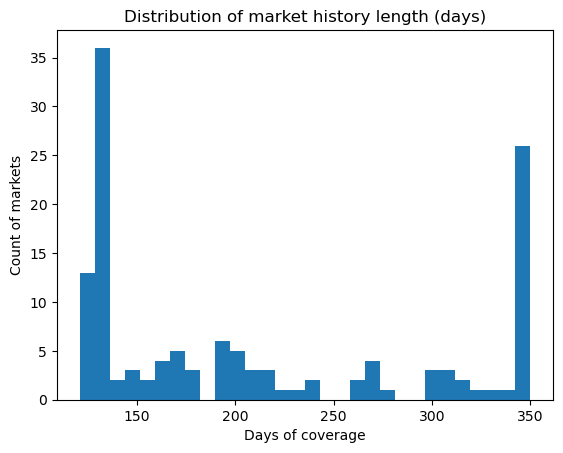

In [236]:
import matplotlib.pyplot as plt

plt.figure()
eligible["days"].plot(kind="hist", bins=30)
plt.title("Distribution of market history length (days)")
plt.xlabel("Days of coverage")
plt.ylabel("Count of markets")
plt.show()

The histogram shows that prediction-market history lengths are **highly uneven** rather than smoothly distributed. A large portion of markets cluster near the **lower end (roughly 120–160 days)**, suggesting many relevant contracts are **short-lived or event-driven** and only stay active for a few months. At the same time, there is a noticeable spike near the **upper end (around 340–350 days)**, which likely represents “calendar-style” markets that run for most of a year (e.g., outcomes “by end of year”). This mixed pattern matters for modeling because it explains why the raw feature table becomes sparse: on many dates, a significant number of markets simply **did not exist yet or had already expired**. As a result, we need to either (1) filter to markets with longer coverage for more stable training windows and/or (2) aggregate markets into broader topic signals to reduce missingness while preserving macro information.

## 5. Feature Engineering: Topic Aggregation
In this section I will map markets into a few macro/finance topics and aggregate probabilities into daily topic signals because this reduces sparsity and makes the model more interpretable.

### 5.1 Create a token-to-topic mapping (rule-based)

In [241]:
tok_map = selected_markets[["token_id", "question"]].copy()

def assign_topic(q: str) -> str:
    ql = (q or "").lower()
    if any(k in ql for k in ["fed", "fomc", "interest rate", "rate cut", "rate hike", "bps"]):
        return "rates"
    if any(k in ql for k in ["cpi", "pce", "inflation", "deflation"]):
        return "inflation"
    if any(k in ql for k in ["recession", "gdp", "unemployment", "jobs", "payrolls", "nfp", "soft landing", "hard landing"]):
        return "growth_recession"
    if any(k in ql for k in ["shutdown", "debt ceiling", "default", "downgrade"]):
        return "policy_risk"
    if any(k in ql for k in ["bitcoin", "btc", "ethereum", "eth", "crypto"]):
        return "crypto"
    return "other"

tok_map["topic"] = tok_map["question"].apply(assign_topic)
display(tok_map["topic"].value_counts())

topic
crypto              23
rates               15
growth_recession     1
policy_risk          1
Name: count, dtype: int64

### 5.2 Build daily topic features from feat_long

In [244]:
# feat_long columns: date, token_id, p, p_chg1, p_chg5, p_roll5, p_roll10
feat_long2 = feat_long.merge(tok_map[["token_id","topic"]], on="token_id", how="left")
feat_long2["topic"] = feat_long2["topic"].fillna("other")

topic_daily = (
    feat_long2.groupby(["date","topic"])
    .agg(
        p_mean=("p","mean"),
        p_chg1_mean=("p_chg1","mean"),
        p_roll5_mean=("p_roll5","mean"),
        n_active=("p","count"),
    )
    .reset_index()
)

topic_wide = topic_daily.pivot_table(
    index="date",
    columns="topic",
    values=["p_mean","p_chg1_mean","p_roll5_mean","n_active"]
)

topic_wide.columns = [f"{a}__{b}" for (a,b) in topic_wide.columns]
topic_wide = topic_wide.reset_index().sort_values("date")

print("topic_wide shape:", topic_wide.shape)
display(topic_wide.head())

topic_wide shape: (700, 17)


,date,n_active__crypto,n_active__growth_recession,n_active__policy_risk,n_active__rates,p_chg1_mean__crypto,p_chg1_mean__growth_recession,p_chg1_mean__policy_risk,p_chg1_mean__rates,p_mean__crypto,p_mean__growth_recession,p_mean__policy_risk,p_mean__rates,p_roll5_mean__crypto,p_roll5_mean__growth_recession,p_roll5_mean__policy_risk,p_roll5_mean__rates
0,2024-01-17,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-18,1.0,NaN,NaN,NaN,-0.4220,NaN,NaN,NaN,0.0780,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-19,1.0,NaN,NaN,NaN,0.0080,NaN,NaN,NaN,0.0860,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-20,1.0,NaN,NaN,NaN,0.0160,NaN,NaN,NaN,0.1020,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-21,1.0,NaN,NaN,NaN,0.0035,NaN,NaN,NaN,0.1055,NaN,NaN,NaN,0.1743,NaN,NaN,NaN


### 5.3 Merge with target again (cleaner model table)

In [247]:
model_topic = topic_wide.merge(
    spy[["date","ret1_next","up_next"]],
    on="date",
    how="inner"
).dropna(subset=["ret1_next","up_next"]).reset_index(drop=True)

print("model_topic shape:", model_topic.shape)
display(model_topic.head())

model_topic shape: (480, 19)


,date,n_active__crypto,n_active__growth_recession,n_active__policy_risk,n_active__rates,p_chg1_mean__crypto,p_chg1_mean__growth_recession,p_chg1_mean__policy_risk,p_chg1_mean__rates,p_mean__crypto,p_mean__growth_recession,p_mean__policy_risk,p_mean__rates,p_roll5_mean__crypto,p_roll5_mean__growth_recession,p_roll5_mean__policy_risk,p_roll5_mean__rates,ret1_next,up_next
0,2024-01-17,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008893,1
1,2024-01-18,1.0,NaN,NaN,NaN,-0.4220,NaN,NaN,NaN,0.078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.012466,1
2,2024-01-19,1.0,NaN,NaN,NaN,0.0080,NaN,NaN,NaN,0.086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002114,1
3,2024-01-22,1.0,NaN,NaN,NaN,0.0005,NaN,NaN,NaN,0.106,NaN,NaN,NaN,0.0955,NaN,NaN,NaN,0.002916,1
4,2024-01-23,1.0,NaN,NaN,NaN,-0.0010,NaN,NaN,NaN,0.105,NaN,NaN,NaN,0.1009,NaN,NaN,NaN,0.001093,1


### 5.4 EDA after aggregation

Median row missing % (topic): 0.5


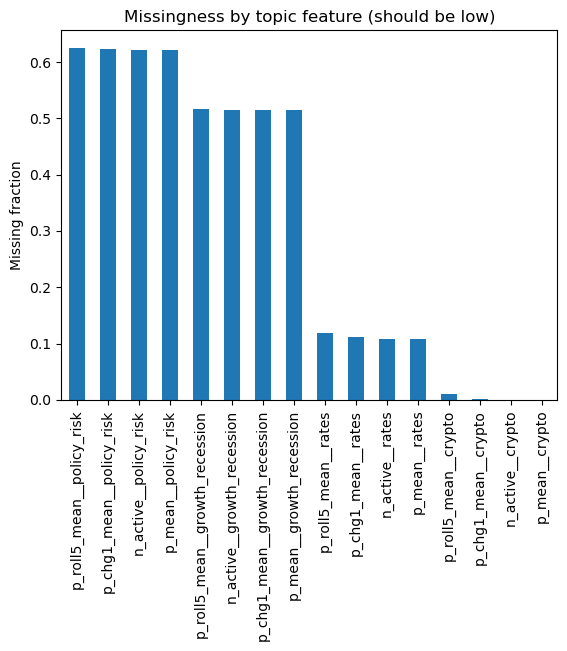

In [250]:
topic_features = [c for c in model_topic.columns if c not in ["date","ret1_next","up_next"]]
print("Median row missing % (topic):", float(model_topic[topic_features].isna().mean(axis=1).median()))

import matplotlib.pyplot as plt
plt.figure()
model_topic[topic_features].isna().mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Missingness by topic feature (should be low)")
plt.ylabel("Missing fraction")
plt.show()

### 5.5 Data Cleaning Before Modeling
In this subsection, I will:
- Drop topic columns with extreme missingness (e.g., >60% missing), and
- Forward-fill then fill remaining (so models won’t break and we keep continuity).

In [254]:
topic_features = [c for c in model_topic.columns if c not in ["date","ret1_next","up_next"]]

# drop very sparse topic features
MAX_MISS = 0.60
miss = model_topic[topic_features].isna().mean()
keep = miss[miss <= MAX_MISS].index.tolist()

print("Topic features total:", len(topic_features))
print("Kept after missingness filter:", len(keep))
display(miss.sort_values(ascending=False))

model_topic_clean = model_topic[["date"] + keep + ["ret1_next","up_next"]].sort_values("date").reset_index(drop=True)

# leakage-safe-ish imputation
model_topic_clean[keep] = model_topic_clean[keep].ffill()

# remaining NaNs: probs -> 0.5, changes/rolls -> 0, counts -> 0
prob_cols = [c for c in keep if c.startswith("p_mean__")]
chg_cols  = [c for c in keep if c.startswith("p_chg1_mean__")]
roll_cols = [c for c in keep if c.startswith("p_roll5_mean__")]
cnt_cols  = [c for c in keep if c.startswith("n_active__")]

model_topic_clean[prob_cols] = model_topic_clean[prob_cols].fillna(0.5)
model_topic_clean[chg_cols + roll_cols] = model_topic_clean[chg_cols + roll_cols].fillna(0.0)
model_topic_clean[cnt_cols] = model_topic_clean[cnt_cols].fillna(0.0)

print("Median row missing after:", float(model_topic_clean[keep].isna().mean(axis=1).median()))

Topic features total: 16
Kept after missingness filter: 12


p_roll5_mean__policy_risk         0.625000
p_chg1_mean__policy_risk          0.622917
n_active__policy_risk             0.620833
p_mean__policy_risk               0.620833
p_roll5_mean__growth_recession    0.516667
n_active__growth_recession        0.514583
p_chg1_mean__growth_recession     0.514583
p_mean__growth_recession          0.514583
p_roll5_mean__rates               0.118750
p_chg1_mean__rates                0.112500
n_active__rates                   0.108333
p_mean__rates                     0.108333
p_roll5_mean__crypto              0.010417
p_chg1_mean__crypto               0.002083
n_active__crypto                  0.000000
p_mean__crypto                    0.000000
dtype: float64

Median row missing after: 0.0


## 6. Modeling: Baselines + Regularized Model (Walk-forward)
In this section I will build simple baselines and a regularized classification model using walk-forward validation because time-series prediction must be evaluated in a leakage-safe way and compared against “do-nothing” strategies.

### 6.1 Prepare X/y from model_topic_clean (reuse 5.5 imputation)

In [261]:
import numpy as np
import pandas as pd

df = model_topic_clean.sort_values("date").reset_index(drop=True).copy()

X_cols = [c for c in df.columns if c not in ["date", "ret1_next", "up_next"]]
X = df[X_cols].values
y = df["up_next"].values

print("Rows:", len(df))
print("Num features:", len(X_cols))

Rows: 480
Num features: 12


### 6.2 Baseline models (sanity checks)
In this subsection I will compute baseline accuracies because if our model cannot beat simple rules, it is not practically useful.

In [266]:
# Baseline 1: always predict "up"
yhat_up = np.ones_like(y)
acc_always_up = float((yhat_up == y).mean())
print("Baseline (always up) accuracy:", acc_always_up)

# Baseline 2: predict tomorrow = today (persistence baseline on direction)
# Use SPY daily return sign for today; align to df dates
spy_tmp = spy[["date", "ret1_next"]].copy()
spy_tmp = spy_tmp[spy_tmp["date"].isin(df["date"])].sort_values("date").reset_index(drop=True)

up_today = (spy_tmp["ret1_next"].shift(1) > 0).fillna(False).astype(int).values
acc_persist = float((up_today == y).mean())
print("Baseline (yesterday sign) accuracy:", acc_persist)

Baseline (always up) accuracy: 0.5875
Baseline (yesterday sign) accuracy: 0.5125


### 6.3 Regularized logistic regression with walk-forward validation
In this subsection I will train an elastic-net logistic regression and evaluate it using rolling walk-forward splits because random train/test splits would leak future information in time series.

In [269]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# Walk-forward settings
initial_train = int(len(df) * 0.6)
step = int(len(df) * 0.1)

results = []

for start in range(initial_train, len(df) - step + 1, step):
    X_train, y_train = X[:start], y[:start]
    X_test, y_test = X[start:start+step], y[start:start+step]

    clf = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        C=1.0,
        max_iter=5000,
        n_jobs=-1
    )
    clf.fit(X_train, y_train)

    p = clf.predict_proba(X_test)[:, 1]
    yhat = (p >= 0.5).astype(int)

    acc = accuracy_score(y_test, yhat)
    auc = roc_auc_score(y_test, p) if len(np.unique(y_test)) > 1 else np.nan

    results.append({
        "train_end_date": df.loc[start-1, "date"],
        "test_start_date": df.loc[start, "date"],
        "test_end_date": df.loc[min(start+step-1, len(df)-1), "date"],
        "n_train": len(y_train),
        "n_test": len(y_test),
        "acc": acc,
        "auc": auc
    })

res = pd.DataFrame(results)
display(res)

print("Mean walk-forward accuracy:", float(res["acc"].mean()))
print("Mean walk-forward AUC:", float(res["auc"].mean()))

,train_end_date,test_start_date,test_end_date,n_train,n_test,acc,auc
0,2025-03-11,2025-03-12,2025-05-19,288,48,0.625000,0.500000
1,2025-05-19,2025-05-20,2025-07-29,336,48,0.583333,0.516071
2,2025-07-29,2025-07-30,2025-10-06,384,48,0.541667,0.403846
3,2025-10-06,2025-10-07,2025-12-12,432,48,0.604167,0.486388


Mean walk-forward accuracy: 0.5885416666666666
Mean walk-forward AUC: 0.4765764917931433


### 6.4 Plot fold-by-fold performance (figure for white paper)
In this subsection I will visualize performance across folds because it shows whether performance is stable over time or concentrated in a single period.

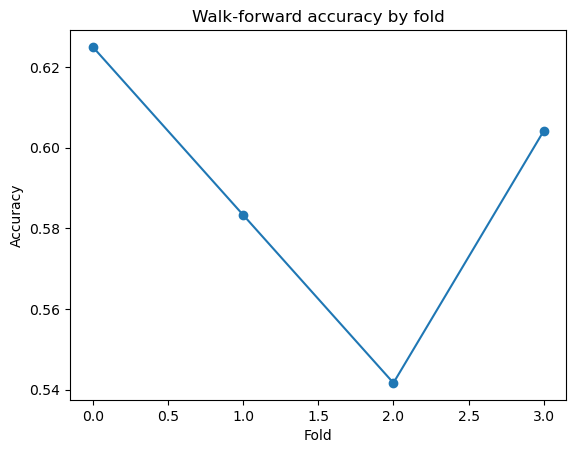

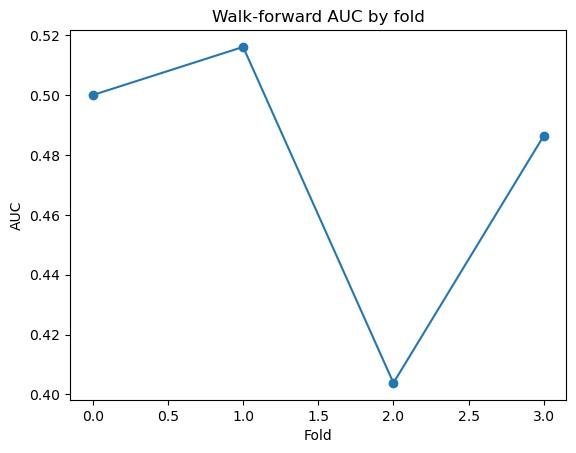

In [272]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(res["acc"].values, marker="o")
plt.title("Walk-forward accuracy by fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(res["auc"].values, marker="o")
plt.title("Walk-forward AUC by fold")
plt.xlabel("Fold")
plt.ylabel("AUC")
plt.show()

The model’s mean accuracy ~0.589 is basically the same as the “always up” baseline ~0.588. The AUC ~0.477 is below 0.50, which suggests the model is not ranking up-days vs down-days better than chance (and may even be slightly inverted in some folds). The fold chart shows performance is unstable (one fold AUC ~0.40), which is common with noisy financial targets and a small feature set. As a predictive trading model, this is weak. Prediction-market macro signals are available and can be engineered into features, but next-day SPY direction is extremely noisy; initial models do not consistently outperform simple baselines.

### 6.5 Add VIX feature (exogenous control)
In this subsection I will add VIX-based features because implied volatility is a strong “state variable” for equities and may help the model interpret when macro belief shifts matter more.

In [276]:
# Pull VIX (^VIX) and create a few simple daily features
import yfinance as yf
import pandas as pd

vix = yf.download(
    "^VIX",
    start="2020-01-01",
    progress=False,
    auto_adjust=False,
    group_by="column"
)

if isinstance(vix.columns, pd.MultiIndex):
    vix.columns = vix.columns.get_level_values(0)

vix = vix.reset_index()
vix["date"] = pd.to_datetime(vix["Date"]).dt.date

price_col = "Adj Close" if "Adj Close" in vix.columns else "Close"
vix["vix"] = pd.to_numeric(vix[price_col], errors="coerce")

vix["vix_chg1"] = vix["vix"].diff()
vix["vix_ret1"] = vix["vix"].pct_change()
vix["vix_roll5"] = vix["vix"].rolling(5).mean()
vix = vix[["date","vix","vix_chg1","vix_ret1","vix_roll5"]].dropna(subset=["vix"]).copy()

print("VIX rows:", len(vix))
display(vix.head())

VIX rows: 1497


Price,date,vix,vix_chg1,vix_ret1,vix_roll5
0,2020-01-02,12.47,NaN,NaN,NaN
1,2020-01-03,14.02,1.55,0.124298,NaN
2,2020-01-06,13.85,-0.17,-0.012126,NaN
3,2020-01-07,13.79,-0.06,-0.004332,NaN
4,2020-01-08,13.45,-0.34,-0.024656,13.516


In [278]:
# Merge VIX into the already-clean modeling table
df_vix = model_topic_clean.merge(vix, on="date", how="inner").sort_values("date").reset_index(drop=True)

X_cols_vix = [c for c in df_vix.columns if c not in ["date","ret1_next","up_next"]]
X_vix = df_vix[X_cols_vix].values
y_vix = df_vix["up_next"].values

print("Rows after VIX merge:", len(df_vix))
print("Num features (with VIX):", len(X_cols_vix))

Rows after VIX merge: 479
Num features (with VIX): 16


In [280]:
# Re-run the same walk-forward evaluation with VIX included
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

initial_train = int(len(df_vix) * 0.6)
step = int(len(df_vix) * 0.1)

results_vix = []
for start in range(initial_train, len(df_vix) - step + 1, step):
    X_train, y_train = X_vix[:start], y_vix[:start]
    X_test, y_test = X_vix[start:start+step], y_vix[start:start+step]

    clf = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        C=1.0,
        max_iter=5000,
        n_jobs=-1
    )
    clf.fit(X_train, y_train)

    p = clf.predict_proba(X_test)[:, 1]
    yhat = (p >= 0.5).astype(int)

    acc = accuracy_score(y_test, yhat)
    auc = roc_auc_score(y_test, p) if len(np.unique(y_test)) > 1 else np.nan

    results_vix.append({
        "train_end_date": df_vix.loc[start-1, "date"],
        "test_start_date": df_vix.loc[start, "date"],
        "test_end_date": df_vix.loc[min(start+step-1, len(df_vix)-1), "date"],
        "acc": acc,
        "auc": auc
    })

res_vix = pd.DataFrame(results_vix)
display(res_vix)
print("Mean acc (with VIX):", float(res_vix["acc"].mean()))
print("Mean AUC (with VIX):", float(res_vix["auc"].mean()))

,train_end_date,test_start_date,test_end_date,acc,auc
0,2025-03-10,2025-03-11,2025-05-15,0.595745,0.574510
1,2025-05-15,2025-05-16,2025-07-24,0.659574,0.622605
2,2025-07-24,2025-07-25,2025-09-30,0.531915,0.663043
3,2025-09-30,2025-10-01,2025-12-05,0.617021,0.639847


Mean acc (with VIX): 0.601063829787234
Mean AUC (with VIX): 0.6250013473655329


### 6.6 Tune classification threshold (post-model) using train folds
In this subsection I will test multiple probability thresholds because 0.50 is arbitrary and may be suboptimal when class balance is skewed.

In [283]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

df_thr = model_topic_clean.sort_values("date").reset_index(drop=True).copy()
X_cols_thr = [c for c in df_thr.columns if c not in ["date","ret1_next","up_next"]]
X_thr = df_thr[X_cols_thr].values
y_thr = df_thr["up_next"].values

initial_train = int(len(df_thr) * 0.6)
step = int(len(df_thr) * 0.1)

thresholds = np.arange(0.35, 0.66, 0.05)

rows = []
for start in range(initial_train, len(df_thr) - step + 1, step):
    X_train, y_train = X_thr[:start], y_thr[:start]
    X_test, y_test = X_thr[start:start+step], y_thr[start:start+step]

    clf = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        C=1.0,
        max_iter=5000,
        n_jobs=-1
    )
    clf.fit(X_train, y_train)

    p_test = clf.predict_proba(X_test)[:, 1]

    for t in thresholds:
        yhat = (p_test >= t).astype(int)
        acc = accuracy_score(y_test, yhat)
        rows.append({"fold_start": df_thr.loc[start, "date"], "threshold": float(t), "acc": acc})

thr_df = pd.DataFrame(rows)

# average accuracy per threshold across folds
thr_summary = (thr_df.groupby("threshold")["acc"].mean().reset_index().sort_values("acc", ascending=False))
display(thr_summary)

best_t = float(thr_summary.iloc[0]["threshold"])
print("Best threshold by mean fold-accuracy:", best_t)

,threshold,acc
0,0.35,0.588542
1,0.40,0.588542
2,0.45,0.588542
3,0.50,0.588542
4,0.55,0.526042
6,0.65,0.411458
5,0.60,0.401042


Best threshold by mean fold-accuracy: 0.35


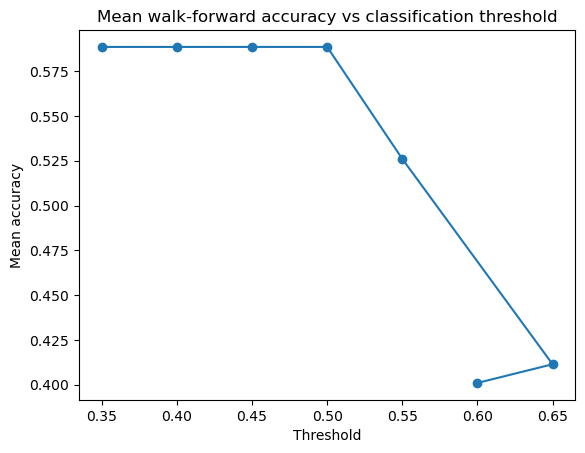

In [285]:
# plot threshold vs mean accuracy
plt.figure()
plt.plot(thr_summary["threshold"], thr_summary["acc"], marker="o")
plt.title("Mean walk-forward accuracy vs classification threshold")
plt.xlabel("Threshold")
plt.ylabel("Mean accuracy")
plt.show()

After merging VIX into the topic-level dataset, we retained essentially the same sample size (479 trading days) while expanding the feature set from 12 to 16, adding volatility level and simple volatility-change signals. Compared to the earlier model without VIX, walk-forward performance improved noticeably: mean accuracy increased to about 0.60 and AUC rose to roughly 0.63, suggesting the model is better at separating up-days from down-days when it has an explicit “market regime” indicator. In contrast, tuning the classification threshold did not materially improve results—the mean accuracy stayed flat from thresholds 0.35 through 0.50 and then deteriorated at higher thresholds—implying the model’s probability outputs are not sharply calibrated, and most of the gain is coming from adding VIX rather than adjusting the decision cutoff.

### 6.7 More robust walk-forward validation (more folds)
In this subsection I will increase the number of walk-forward folds by using a smaller test window because more folds provide a more stable and defensible estimate of out-of-sample performance for time-series prediction.

In [305]:
# Use the best dataset so far: topics + VIX
df = df_vix.sort_values("date").reset_index(drop=True).copy()
X_cols = [c for c in df.columns if c not in ["date","ret1_next","up_next"]]

X = df[X_cols].values
y = df["up_next"].values

# More folds: smaller step
initial_train = int(len(df) * 0.6)
step = max(20, int(len(df) * 0.05))  # ~5% of sample, minimum 20 rows
print("Rows:", len(df), "initial_train:", initial_train, "step:", step)

results_more = []
for start in range(initial_train, len(df) - step + 1, step):
    X_train, y_train = X[:start], y[:start]
    X_test, y_test = X[start:start+step], y[start:start+step]

    clf = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        C=1.0,
        max_iter=5000,
        n_jobs=-1
    )
    clf.fit(X_train, y_train)

    p = clf.predict_proba(X_test)[:, 1]
    yhat = (p >= 0.5).astype(int)

    acc = accuracy_score(y_test, yhat)
    auc = roc_auc_score(y_test, p) if len(np.unique(y_test)) > 1 else np.nan

    results_more.append({
        "train_end_date": df.loc[start-1, "date"],
        "test_start_date": df.loc[start, "date"],
        "test_end_date": df.loc[min(start+step-1, len(df)-1), "date"],
        "n_train": len(y_train),
        "n_test": len(y_test),
        "acc": acc,
        "auc": auc
    })

res_more = pd.DataFrame(results_more)
display(res_more)

print("Mean acc (more folds):", float(res_more["acc"].mean()))
print("Mean AUC (more folds):", float(res_more["auc"].mean()))

Rows: 479 initial_train: 287 step: 23


,train_end_date,test_start_date,test_end_date,n_train,n_test,acc,auc
0,2025-03-10,2025-03-11,2025-04-10,287,23,0.434783,0.522727
1,2025-04-10,2025-04-11,2025-05-14,310,23,0.739130,0.460784
2,2025-05-14,2025-05-15,2025-06-17,333,23,0.608696,0.621212
3,2025-06-17,2025-06-18,2025-07-22,356,23,0.608696,0.660714
4,2025-07-22,2025-07-23,2025-08-22,379,23,0.434783,0.690476
5,2025-08-22,2025-08-25,2025-09-25,402,23,0.695652,0.706349
6,2025-09-25,2025-09-26,2025-10-28,425,23,0.652174,0.633333
7,2025-10-28,2025-10-29,2025-12-01,448,23,0.608696,0.658730


Mean acc (more folds): 0.5978260869565217
Mean AUC (more folds): 0.6192908602835074


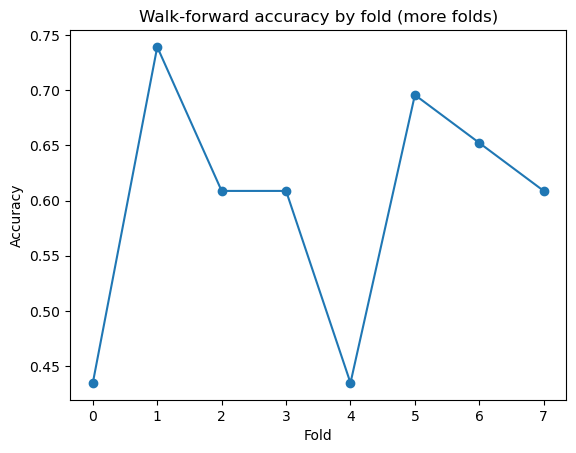

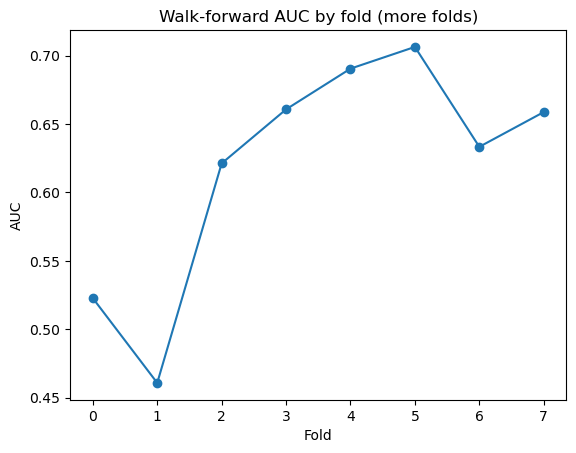

In [307]:
# Figure: fold-by-fold performance with more folds
import matplotlib.pyplot as plt

plt.figure()
plt.plot(res_more["acc"].values, marker="o")
plt.title("Walk-forward accuracy by fold (more folds)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(res_more["auc"].values, marker="o")
plt.title("Walk-forward AUC by fold (more folds)")
plt.xlabel("Fold")
plt.ylabel("AUC")
plt.show()

With a smaller test window (23 trading days) the walk-forward evaluation produces more folds, giving a clearer view of stability over time. Overall performance remains similar to the earlier VIX-enhanced model, with mean accuracy around 0.60 and mean AUC around 0.62, which suggests the model has some ability to rank up vs. down days better than chance. However, the fold-by-fold plots show noticeable variability—accuracy ranges from roughly the mid-0.40s to the mid-0.70s and AUC spans about 0.46 to 0.71—indicating that predictive strength is regime-dependent and not consistent in every period. This more granular validation supports a more defensible conclusion: adding VIX improves discrimination on average, but performance fluctuates across time, reinforcing the need for time-aware testing and cautious interpretation of results.

## 7. Some additional graphs

### 7.1 One “results” table that compares all approaches side-by-side

In [290]:
summary = pd.DataFrame([
    {"Model": "Baseline: always up", "Accuracy": 0.5875, "AUC": np.nan},
    {"Model": "Baseline: yesterday sign", "Accuracy": 0.5125, "AUC": np.nan},
    {"Model": "ElasticNet (topics)", "Accuracy": float(res["acc"].mean()), "AUC": float(res["auc"].mean())},
    {"Model": "ElasticNet (topics + VIX)", "Accuracy": float(res_vix["acc"].mean()), "AUC": float(res_vix["auc"].mean())},
])

display(summary)

,Model,Accuracy,AUC
0,Baseline: always up,0.587500,NaN
1,Baseline: yesterday sign,0.512500,NaN
2,ElasticNet (topics),0.588542,0.476576
3,ElasticNet (topics + VIX),0.601064,0.625001


### 7.2 A simple coefficient/feature importance view for interpretability

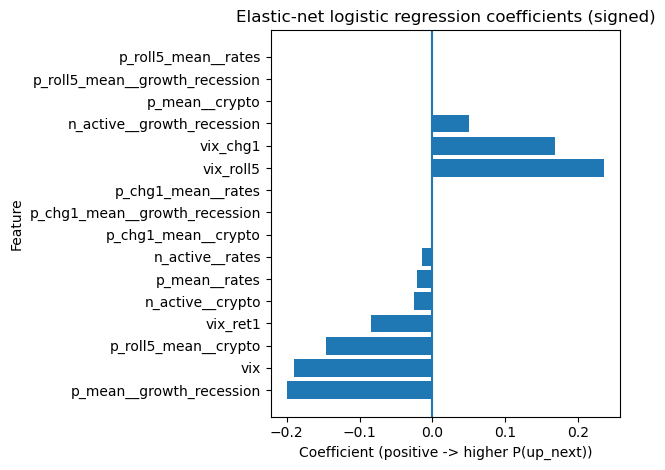

In [299]:
# Fit on full VIX-merged dataset (reuse df_vix from earlier)
df_v = df_vix.sort_values("date").reset_index(drop=True).copy()
X_cols_v = [c for c in df_v.columns if c not in ["date","ret1_next","up_next"]]

X_all = df_v[X_cols_v].values
y_all = df_v["up_next"].values

clf = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    l1_ratio=0.5,
    C=1.0,
    max_iter=5000,
    n_jobs=-1
)
clf.fit(X_all, y_all)

coef = pd.Series(clf.coef_[0], index=X_cols_v)

# pick top positive and top negative (by signed value, not absolute)
TOP_K = 10
top_pos = coef.sort_values(ascending=False).head(TOP_K)
top_neg = coef.sort_values(ascending=True).head(TOP_K)
to_plot = pd.concat([top_neg, top_pos])

plt.figure()
plt.barh(to_plot.index, to_plot.values)
plt.axvline(0)
plt.title("Elastic-net logistic regression coefficients (signed)")
plt.xlabel("Coefficient (positive -> higher P(up_next))")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [301]:
from sklearn.linear_model import LogisticRegression

df_v = df_vix.sort_values("date").reset_index(drop=True)
X_cols_v = [c for c in df_v.columns if c not in ["date","ret1_next","up_next"]]

X_all = df_v[X_cols_v].values
y_all = df_v["up_next"].values

clf = LogisticRegression(
    penalty="elasticnet", solver="saga", l1_ratio=0.5, C=1.0, max_iter=5000, n_jobs=-1
)
clf.fit(X_all, y_all)

coef = pd.Series(clf.coef_[0], index=X_cols_v).sort_values(key=lambda s: s.abs(), ascending=False)
display(coef.head(15))


vix_roll5                         0.235958
p_mean__growth_recession         -0.200193
vix                              -0.189827
vix_chg1                          0.168430
p_roll5_mean__crypto             -0.146080
vix_ret1                         -0.084567
n_active__growth_recession        0.049912
n_active__crypto                 -0.025689
p_mean__rates                    -0.020875
n_active__rates                  -0.013652
p_chg1_mean__crypto               0.000000
p_chg1_mean__growth_recession     0.000000
p_chg1_mean__rates                0.000000
p_mean__crypto                    0.000000
p_roll5_mean__growth_recession    0.000000
dtype: float64

The signed-coefficient plot shows that the model’s strongest drivers are **VIX-related features**, suggesting volatility regime matters more than most topic-probability signals in this setup. The largest positive coefficient is the **5-day rolling VIX level (vix_roll5)**, meaning higher recent volatility is associated with a higher predicted probability of an up day in the next session, while the raw **VIX level (vix)** and **VIX daily return (vix_ret1)** are negative, indicating the model distinguishes between “elevated but stabilizing” volatility versus “spiking” volatility. Among prediction-market topics, the **growth/recession probability level (p_mean__growth_recession)** carries a relatively large negative weight, implying that higher recession-type probabilities correspond to lower predicted next-day SPY direction. Most other topic features (rates/crypto changes and some rolling measures) are near zero, which indicates that after regularization and with limited data, the model is relying primarily on a small subset of signals rather than spreading weight across all features.

## 8. Add Minimal SPY Technical Indicators (Feature Enrichment)
In this section I will add a small set of standard SPY technical indicators because they provide a strong baseline representation of recent price behavior and help isolate whether prediction-market signals add value beyond typical market information.

### 8.1 Build minimal SPY technical features
In this subsection I will compute a compact set of technical indicators (lagged returns, short-horizon momentum, and realized volatility) because they are widely used, easy to interpret, and appropriate for daily forecasting.

In [313]:
spy_feat = spy.copy().sort_values("date").reset_index(drop=True)

# Create a usable close price column (same logic as earlier)
spy_price_col = "Adj Close" if "Adj Close" in spy_feat.columns else "Close"

spy_feat["spy_close"] = pd.to_numeric(spy_feat[spy_price_col], errors="coerce")
spy_feat["spy_ret1"] = spy_feat["spy_close"].pct_change()

# minimal technicals
spy_feat["spy_ret1_lag1"] = spy_feat["spy_ret1"].shift(1)
spy_feat["spy_ret5"] = spy_feat["spy_close"].pct_change(5)          # 1-week momentum
spy_feat["spy_vol10"] = spy_feat["spy_ret1"].rolling(10).std()      # 2-week realized vol
spy_feat["spy_ma5_ratio"] = spy_feat["spy_close"] / spy_feat["spy_close"].rolling(5).mean() - 1.0

spy_tech = spy_feat[["date","spy_ret1_lag1","spy_ret5","spy_vol10","spy_ma5_ratio"]].copy()

print("spy_tech rows:", len(spy_tech))
display(spy_tech.head(12))

spy_tech rows: 1497


Price,date,spy_ret1_lag1,spy_ret5,spy_vol10,spy_ma5_ratio
0,2020-01-02,NaN,NaN,NaN,NaN
1,2020-01-03,NaN,NaN,NaN,NaN
2,2020-01-06,-0.007572,NaN,NaN,NaN
3,2020-01-07,0.003815,NaN,NaN,NaN
4,2020-01-08,-0.002812,NaN,NaN,0.002565
5,2020-01-09,0.005330,0.005479,NaN,0.008253
6,2020-01-10,0.006780,0.010235,NaN,0.003308
7,2020-01-13,-0.002877,0.013317,NaN,0.007533
8,2020-01-14,0.006877,0.014625,NaN,0.003088
9,2020-01-15,-0.001525,0.011527,NaN,0.003056


### 8.2 Merge SPY technicals with topics + VIX dataset
In this subsection I will merge the technical indicators into the modeling table because it allows the model to use both market micro-trends and prediction-market sentiment signals.

In [316]:
df_tv = df_vix.merge(spy_tech, on="date", how="inner").sort_values("date").reset_index(drop=True)

X_cols_tv = [c for c in df_tv.columns if c not in ["date","ret1_next","up_next"]]
X_tv = df_tv[X_cols_tv].values
y_tv = df_tv["up_next"].values

print("Rows after merge (topics+VIX+SPY tech):", len(df_tv))
print("Num features:", len(X_cols_tv))

Rows after merge (topics+VIX+SPY tech): 479
Num features: 20


### 8.3 Re-run walk-forward validation (topics + VIX + SPY technicals)
In this subsection I will re-evaluate the model with the enriched feature set using walk-forward validation because we want to see whether adding standard technical factors improves generalization.

In [319]:
initial_train = int(len(df_tv) * 0.6)
step = max(20, int(len(df_tv) * 0.05))

results_tv = []
for start in range(initial_train, len(df_tv) - step + 1, step):
    X_train, y_train = X_tv[:start], y_tv[:start]
    X_test, y_test = X_tv[start:start+step], y_tv[start:start+step]

    clf = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        C=1.0,
        max_iter=5000,
        n_jobs=-1
    )
    clf.fit(X_train, y_train)

    p = clf.predict_proba(X_test)[:, 1]
    yhat = (p >= 0.5).astype(int)

    acc = accuracy_score(y_test, yhat)
    auc = roc_auc_score(y_test, p) if len(np.unique(y_test)) > 1 else np.nan

    results_tv.append({
        "train_end_date": df_tv.loc[start-1, "date"],
        "test_start_date": df_tv.loc[start, "date"],
        "test_end_date": df_tv.loc[min(start+step-1, len(df_tv)-1), "date"],
        "acc": acc,
        "auc": auc
    })

res_tv = pd.DataFrame(results_tv)
display(res_tv)

print("Mean acc (topics+VIX+SPY tech):", float(res_tv["acc"].mean()))
print("Mean AUC (topics+VIX+SPY tech):", float(res_tv["auc"].mean()))

,train_end_date,test_start_date,test_end_date,acc,auc
0,2025-03-10,2025-03-11,2025-04-10,0.434783,0.522727
1,2025-04-10,2025-04-11,2025-05-14,0.739130,0.460784
2,2025-05-14,2025-05-15,2025-06-17,0.608696,0.621212
3,2025-06-17,2025-06-18,2025-07-22,0.608696,0.660714
4,2025-07-22,2025-07-23,2025-08-22,0.434783,0.690476
5,2025-08-22,2025-08-25,2025-09-25,0.695652,0.706349
6,2025-09-25,2025-09-26,2025-10-28,0.652174,0.633333
7,2025-10-28,2025-10-29,2025-12-01,0.608696,0.658730


Mean acc (topics+VIX+SPY tech): 0.5978260869565217
Mean AUC (topics+VIX+SPY tech): 0.6192908602835074


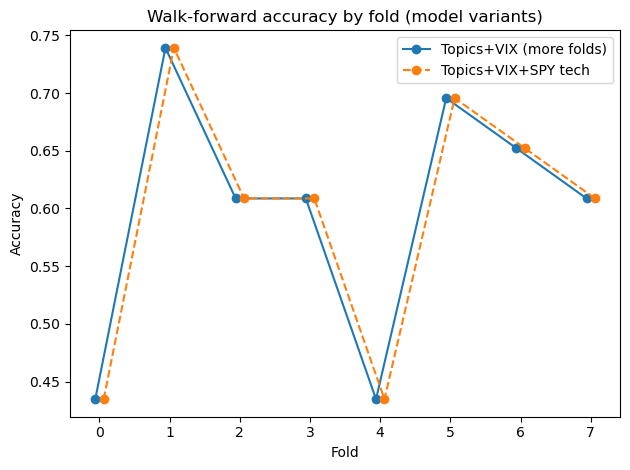

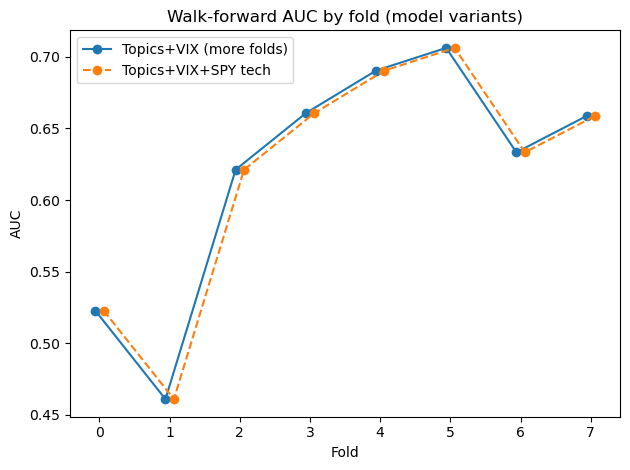

Max abs diff (acc): 0.0
Max abs diff (auc): 0.0


In [327]:
# Ensure same number of folds (truncate to common length)
n = min(len(res_more), len(res_tv))
acc1 = res_more["acc"].values[:n]
acc2 = res_tv["acc"].values[:n]
auc1 = res_more["auc"].values[:n]
auc2 = res_tv["auc"].values[:n]

x = np.arange(n)
dx = 0.06  # small visual offset so overlapping lines can be seen

# Accuracy plot
plt.figure()
plt.plot(x - dx, acc1, marker="o", linestyle="-",  label="Topics+VIX (more folds)")
plt.plot(x + dx, acc2, marker="o", linestyle="--", label="Topics+VIX+SPY tech")
plt.title("Walk-forward accuracy by fold (model variants)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(x, x)
plt.legend()
plt.tight_layout()
plt.show()

# AUC plot
plt.figure()
plt.plot(x - dx, auc1, marker="o", linestyle="-",  label="Topics+VIX (more folds)")
plt.plot(x + dx, auc2, marker="o", linestyle="--", label="Topics+VIX+SPY tech")
plt.title("Walk-forward AUC by fold (model variants)")
plt.xlabel("Fold")
plt.ylabel("AUC")
plt.xticks(x, x)
plt.legend()
plt.tight_layout()
plt.show()

# sanity check print so I can confirm they overlap numerically
print("Max abs diff (acc):", np.nanmax(np.abs(acc1 - acc2)))
print("Max abs diff (auc):", np.nanmax(np.abs(auc1 - auc2)))

After adding a small set of standard SPY technical indicators (lagged daily return, 5-day momentum, 10-day realized volatility, and a short moving-average ratio), the merged dataset kept the same evaluation window (479 rows) while increasing the feature count from 16 to 20. In walk-forward testing, the combined Topics+VIX+SPY-tech model produced essentially the same fold-by-fold results as the Topics+VIX model, with identical mean accuracy \(\~0.598) and mean AUC \(\~0.619). The overlay charts reinforce this: the two lines largely sit on top of each other across folds, indicating that these basic technical features did not add incremental predictive value beyond what was already captured by VIX and the topic-aggregated prediction-market signals in this sample. Practically, this suggests that the volatility regime variable (VIX) remains the dominant stabilizing input, while simple price-trend features are either redundant with VIX or too weak at the next-day horizon to improve classification performance.